# Figure 1A

In [10]:
import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
import napari
from cellpose import models
from cellpose.utils import stitch3D

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 

# Load in example image to show slices
name = "ExpBSc2_TL_ITD1_20x_260513_F08"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}_cropped.ims"))[frame, channel] 
print(cropped.shape)
# segmentation = tifffile.imread(os.path.join(input_directory, f"{name}_segmented.tif"))[frame, :]
# print(segmentation.shape)


# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\20260511 CARE BSc\Train Low segmenter\models\low_input"
#     )
# model = models.CellposeModel(
#         gpu=("cuda" == "cuda"), pretrained_model=r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_high_quality_model"
#     )


# cp = []
# for z in range(cropped.shape[0]):
#     print(f"Running cellpose on z-slice {z}...")
#     masks, _, _ = model.eval(cropped[z],
#                 diameter=None,
#                 normalize=True,
#                 flow_threshold=0.4,
#                 invert=False,
#                 resample=True,
#                 do_3D=False,
#                 progress=None,
#                 )
#     cp.append(masks)
# cp = np.stack(cp, axis=0)
# cp = stitch3D(cp)
# tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 0.3)
# nuclogic2 = stitch_3d(nuclogic, cropped)

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)
viewer.add_image(cropped[:, y_half, x_half], contrast_limits=contrast, scale=scale)
viewer.add_labels(cp[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", visible=False)
viewer.add_labels(nuclogic[:, y_half, x_half], scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_labels(cp, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(nuclogic2, scale=scale, iso_gradient_mode="smooth", visible=False)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

(63, 294, 290)
Cellpose seg cell numbers: 310
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2095 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 311 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 58 breaks.
    Iteration 2: Made 22 breaks.
    Iteration 3: Made 16 breaks.
    Iteration 4: Made 3 breaks.
Finding touching cell pairs...
Found 347 pairs of touching cells.
Splitted 70 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 10 small cells, and removed 15 cells without suitable neighbors.
Final stitched mask has 385 cells.
slice(0, 147, None) slice(0, 290, None

Figure 2

In [1]:
# Figure 2A

import os
import tifffile
from imaris_ims_file_reader.ims import ims
import numpy as np
import napari
import scipy.ndimage

# import utils from the parent directory
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.stitch_3d import stitch_3d 
from utils.expand_mask import expand_mask_3d

# Load in example image to show slices
name = "ExpBSc2_TL_ITD1_20x_260513_F08"
input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = ims(os.path.join(input_directory, f"{name}_cropped.ims"))[frame, channel] 
print(cropped.shape)

# cp = []
# for z in range(cropped.shape[0]):
#     print(f"Running cellpose on z-slice {z}...")
#     masks, _, _ = model.eval(cropped[z],
#                 diameter=None,
#                 normalize=True,
#                 flow_threshold=0.4,
#                 invert=False,
#                 resample=True,
#                 do_3D=False,
#                 progress=None,
#                 )
#     cp.append(masks)
# cp = np.stack(cp, axis=0)
# cp = stitch3D(cp)
# tifffile.imwrite(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"), cp.astype(np.uint16))

cp = tifffile.imread(os.path.join(input_directory, f"{name}_cp_segmented_frame_{frame}.tif"))
print(f"Cellpose seg cell numbers: {len(np.unique(cp))}")
nuclogic = stitch_3d(cp, cropped, breaking_threshold = 2)
# nuclogic2 = stitch_3d(nuclogic, cropped)

# Show in napari
contrast = (np.median(cropped) * 1.2, np.percentile(cropped, 99.98))
scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)
viewer.dims.ndisplay = 3
y_half = slice(0, cropped.shape[1] // 2)
x_half = slice(0, cropped.shape[2])
print(y_half, x_half)

selected_mask_cp = cp == 167  # show only the mask for cell 174
selected_mask_cp = np.where(selected_mask_cp, cp, 0)  # create a masked image where only the selected cell is visible
# cropped_masked = expand_mask_3d(selected_mask_cp, dilation_size_um = 2, voxel_size=scale)  # dilate the mask to make it more visible
# cropped_masked = np.where(cropped_masked, cropped, 0)  # create a masked image where only the selected cell is visible
selected_ids_nuclogic = [166, 336]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible
# target_z = np.where(selected_mask_nuclogic)[0].min() + 5
# nuclogic_display = nuclogic.copy()
# # replace both cell IDs only in that single slice
# nuclogic_display[target_z][np.isin(nuclogic_display[target_z], [166, 336])] = 166


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)
# viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
# viewer.reset_view()
# viewer.camera.center = (83.24123779650657, 96.3297331771258, 59.20690029145916)
# viewer.camera.angles = (180, 0.6526549938471702, 0.413991687612314)
# viewer.camera.zoom = 12.308777811410637
# @viewer.bind_key('c')  # press 'c' to capture camera state
# def print_camera(viewer):
#     print(f"viewer.camera.center = {viewer.camera.center}")
#     print(f"viewer.camera.angles = {viewer.camera.angles}")
#     print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# # make scale bar visible
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# #toggle grid mode on
# viewer.grid.enabled = True
# viewer.theme = 'light'

# # save screenshot
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# napari.run()
# # viewer.screenshot(path=os.path.join(output_directory, "2A.png"), canvas_only=True, scale = 2)

Opening readonly file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

Closing file: C:\Users\6331823\Local SSD\NucLogic paper figure data\ExpBSc2_TL_ITD1_20x_260513_F08_cropped.ims 

(63, 294, 290)
Cellpose seg cell numbers: 310
Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2095 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 311 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 0.9032813846033362, 0.7951773315819103, 1.2251157407407407, 1.1290666666666669, 0.8769322235434006, 1.387234809242827, 0.8830795748348177, 0.8891657766702267, 0.8779217558435117, 0]
  Intensity break scores: [0, 0.8492980268904382, 0.91223470190151, 0.8789276647534391, 0.9990466362153788, 1.387835958498404, 1.022743029860302, 0.9343847063029113, 1.046150241330675, 1.

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\standardize_color.py:91: UserWarning: Empty string detected. Returning black instead.
  warnings.warn(


<Labels layer 'selected_mask_cp' at 0x1d900553a90>

In [2]:
# print the most bottom nonzero slice of the selected mask to check if the bottom part of the cell is still visible
print("Most bottom nonzero slice of the selected mask:")
print(np.where(selected_mask_nuclogic)[0].min())

Most bottom nonzero slice of the selected mask:
28


In [ ]:
# Figure 2A_bottom
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)


# viewer.add_image(cropped, contrast_limits=contrast, scale=scale)
# viewer.add_image(cropped_masked, contrast_limits=(contrast[0], contrast[1]/1.7), scale=scale, colormap="Greys")
viewer.add_labels(selected_mask_cp, scale=scale, colormap={0: "", 167: "magenta"}, iso_gradient_mode="smooth", visible=True, opacity=1)
viewer.add_labels(nuclogic_display, scale=scale, colormap={0: "", 166: "magenta", 336: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "2A_bottom.png"), canvas_only=True, scale = 3)

c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [2]:
# Figure 2b final
# Show in napari

scale = (2.5, 0.64, 0.64)
viewer = napari.Viewer(ndisplay=3)

selected_ids_nuclogic = [166, 343]
selected_mask_nuclogic = np.isin(nuclogic, selected_ids_nuclogic)  # create mask where the selected cells are visible
# selected_mask_nuclogic = np.where(selected_mask_nuclogic, nuclogic, 0)  # create a masked image where only the selected cells are visible

viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", visible=False)
nuclogic2 = stitch_3d(nuclogic, cropped, breaking_threshold = 2)
viewer.add_labels(nuclogic2, scale=scale, iso_gradient_mode="smooth", visible=False)
# viewer.add_labels(selected_mask_nuclogic, scale=scale, colormap={0: "", 166: "magenta", 343: "lime"}, iso_gradient_mode="smooth", visible=True, opacity=1)


# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.reset_view()
viewer.camera.center = (81.7789406621335, 22.667029017368154, 88.64139740486563)
viewer.camera.angles = (178.06352653830456, -84.03938801581167, 2.1125919814583987)
viewer.camera.zoom = 12.308777811410637
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "2B_final.png"), canvas_only=True, scale = 3)

Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 2213 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 364 cells formed.
Starting iterative breaking of cells
Cell 166 break scores:
  Volume break scores: [0, 2.3714285714285714, 0.8465608465608466, 0.8779213238496153, 0.9096137152777779, 1.0520833333333335, 0.8469757866875796, 0.8603703703703703, 0]
  Intensity break scores: [0, 0.9282447968593451, 1.0870938958260137, 1.217307202571666, 0.996838532179134, 0.8590281509355322, 0.9518647819844411, 1.1132058805582201, 0]
  Line break scores (up): [0.         0.         1.15613345 3.80633368 2.32554158 0.21497982
 0.41075812 0.19655939 0.0941902 ]
  Line distances (up): [0.57806672 1.15613345 0.57806672 3.80633368 4.70905905 5.3968046
 6.49530828 7.79037133 9.17962459]
  Line break scores (down): [0.         1.16928662 1.79121567 0.94175093 0.13594289 

array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [2]:
# Figure synthetic data
# Code to create synthetic data for testing the stitching algorithm
from skimage.draw import ellipsoid
import napari
import os
from scipy.ndimage import zoom, gaussian_filter
import numpy as np
from scipy.ndimage import binary_dilation


def make_cell(radius_Z, radius_Y, radius_X, intensity=255):
    """Create a binary ellipsoidal cell"""
    cell = ellipsoid(radius_Z, radius_Y, radius_X)
    cell = cell.astype(np.uint16) * intensity
    return cell


def paste_cell(volume, mask, cell, position, label):
    cz, cy, cx = position.astype(int)
    dz, dy, dx = cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(volume.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(volume.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(volume.shape[2], cx + hx + 1)

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    if subcell.size == 0:
        return False

    volume[z0:z1, y0:y1, x0:x1] = np.maximum(volume[z0:z1, y0:y1, x0:x1], subcell)
    mask[z0:z1, y0:y1, x0:x1][subcell > 0] = label
    return True

from scipy.ndimage import affine_transform


def _rotation_matrix(from_vec, to_vec):
    a = from_vec / (np.linalg.norm(from_vec) + 1e-8)
    b = to_vec / (np.linalg.norm(to_vec) + 1e-8)
    v = np.cross(a, b)
    c = np.dot(a, b)
    if np.isclose(c, 1.0):
        return np.eye(3)
    if np.isclose(c, -1.0):
        # 180° flip around any perpendicular axis
        perp = np.array([1.0, 0.0, 0.0])
        if np.allclose(a, perp):
            perp = np.array([0.0, 1.0, 0.0])
        v = perp - a * np.dot(perp, a)
        v /= np.linalg.norm(v)
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        return np.eye(3) + 2 * vx @ vx
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx * ((1 - c) / (np.linalg.norm(v) ** 2 + 1e-8))


def orient_cell(cell, direction_vec):
    base = np.array([1.0, 0.0, 0.0])  # +z axis in (z, y, x) ordering
    pad = int(max(cell.shape) * 0.75)
    padded = np.pad(
        cell,
        ((pad, pad), (pad, pad), (pad, pad)),
        mode="constant",
        constant_values=0,
    )
    R = _rotation_matrix(base, direction_vec)
    center = (np.array(padded.shape) - 1) / 2
    matrix = R.T
    offset = center - matrix @ center
    rotated = affine_transform(
        padded,
        matrix=matrix,
        offset=offset,
        order=1,
        mode="constant",
        cval=0,
    )
    return rotated.astype(cell.dtype)


def can_place(mask, cell, position, min_gap=4):
    dilated_cell = binary_dilation(cell > 0, iterations=min_gap)
    cz, cy, cx = position.astype(int)
    dz, dy, dx = dilated_cell.shape
    hz, hy, hx = dz // 2, dy // 2, dx // 2

    z0, z1 = max(0, cz - hz), min(mask.shape[0], cz + hz + 1)
    y0, y1 = max(0, cy - hy), min(mask.shape[1], cy + hy + 1)
    x0, x1 = max(0, cx - hx), min(mask.shape[2], cx + hx + 1)

    if z0 >= z1 or y0 >= y1 or x0 >= x1:
        return False

    cell_z0 = hz - (cz - z0)
    cell_y0 = hy - (cy - y0)
    cell_x0 = hx - (cx - x0)

    subcell = dilated_cell[
        cell_z0 : cell_z0 + (z1 - z0),
        cell_y0 : cell_y0 + (y1 - y0),
        cell_x0 : cell_x0 + (x1 - x0),
    ]

    return np.all(mask[z0:z1, y0:y1, x0:x1][subcell > 0] == 0)

def generate_synthetic_organoid(number_of_cells = 250, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250):
    volume = np.zeros(vol_shape, dtype=np.uint16)
    mask = np.zeros_like(volume)

    center = np.array(vol_shape) // 2

    for cell_idx in range(number_of_cells):
        # create a binomial distrubution around the radii with the arms reaching the randomness value
        rand_radius_X = int(radius_X + np.random.uniform(-randomness, randomness) * radius_X)
        rand_radius_Y = int(radius_Y + np.random.uniform(-randomness, randomness) * radius_Y)
        rand_radius_Z = int(radius_Z + np.random.uniform(-randomness, randomness) * radius_Z)
        cell = make_cell(rand_radius_Z, rand_radius_Y, rand_radius_X, intensity=255)

        placed = False
        for attempt in range(max_attempts):
            # get a random position at distance of organoid_size/2 from center
            u = np.random.uniform(-1, 1)  # cos(theta)
            phi = np.random.uniform(0, 2 * np.pi)
            theta = np.arccos(u)
            r = organoid_size / 2 # controls how far from center the cells are placed
            pos_z = int(center[0] + r * u)
            sin_theta = np.sqrt(1 - u * u)
            pos_y = int(center[1] + r * sin_theta * np.cos(phi))
            pos_x = int(center[2] + r * sin_theta * np.sin(phi))
            position = np.array([pos_z, pos_y, pos_x])

            # place the cell in the volume at the random position
            direction = center - position  # point toward organoid center
            oriented_cell = orient_cell(cell, direction)

            if not can_place(mask, oriented_cell, position):
                continue

            paste_success = paste_cell(volume, mask, oriented_cell, position, label=cell_idx + 1)
            if paste_success:
                placed = True
                print(
                    f"Cell {cell_idx+1}: position=({pos_z}, {pos_y}, {pos_x}), radii=({rand_radius_Z}, {rand_radius_Y}, {rand_radius_X})"
                )
                break

        if not placed:
            print(f"Cell {cell_idx}: skipped after {max_attempts} attempts")

    return volume, mask

seed = 1
np.random.seed(seed)
rng = np.random.default_rng(seed)

def generate_synthetic_data(number_of_cells = 250, max_attempts = 30, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (300,300,300), organoid_size = 250):

    synthetic_organoid, synthetic_mask = generate_synthetic_organoid(number_of_cells = number_of_cells, max_attempts = max_attempts, radius_X = radius_X, radius_Y = radius_Y, radius_Z = radius_Z, randomness = randomness, vol_shape = vol_shape, organoid_size = organoid_size)
    rescale = ((synthetic_organoid.shape[0] / (2.5 / 0.64) / synthetic_organoid.shape[0]), 1.0, 1.0)
    synthetic_organoid = zoom(synthetic_organoid, zoom=rescale, order=1)
    mask = zoom(synthetic_mask, zoom=rescale, order=0)
    output_directory = r"C:\Users\6331823\Local SSD\Fake_data"

    unique_labels = np.unique(mask)
    unique_labels = unique_labels[unique_labels > 0]

    brightness_volume = np.zeros_like(synthetic_organoid, dtype=np.float32)

    for lbl in unique_labels:
        cell_voxels = mask == lbl
        cell_mean = np.clip(rng.normal(150, 30), 50, 300)
        cell_noise = rng.normal(loc=cell_mean, scale=5, size=cell_voxels.sum())
        lo = max(150, cell_mean - 10)
        hi = min(250, cell_mean + 10)
        brightness_volume[cell_voxels] = np.clip(cell_noise, lo, hi)

    brightness_volume = brightness_volume.astype(np.uint16)


    # # create noise and PSF
    # gaussian_volume = gaussian_filter(
    #     brightness_volume.astype(np.float32), sigma=(1.6, 0.6, 0.6)
    # )
    # treat the per-cell brightness as photon counts (so Poisson SNR is meaningful)
    signal_photons = brightness_volume.astype(np.float32)

    # --- PSF (optics) : anisotropic, effective = diffraction floor + tissue scatter ---
    # em, NA, n = 0.680, 1.0, 1.33                 # 638 ex -> ~680 em far-red, water immersion
    # vox = np.array([2.5, 0.64, 0.64])            # (z, y, x) um after the zoom
    # fwhm = np.array([1.4 * n * em / NA**2, 0.51 * em / NA, 0.51 * em / NA])
    # sigma_diffraction = fwhm / 2.355 / vox       # ~sub-voxel at this sampling
    # sigma_eff = np.maximum(sigma_diffraction, [2, 0.7, 0.7])   # your values, as scatter floor
    blurred = np.empty_like(signal_photons)
    nz = signal_photons.shape[0]
    for z in range(nz):
        depth_frac = (z / nz)**0.5                      # 0 = bottom (near objective), 1 = deep
        sz = 1 + 1.6 * depth_frac              # axial blur grows with depth
        sxy = 0.5 + 0.5 * depth_frac             # lateral blur grows with depth
        # blur a small Z-window around slice z so axial smear is captured
        z0, z1 = max(0, z-4), min(nz, z+5)
        blurred[z] = gaussian_filter(signal_photons[z0:z1], sigma=(sz, sxy, sxy))[z-z0]

    # --- depth-dependent signal loss (absorption/scattering deeper in the organoid) ---
    depth = np.linspace(0.0, 1.0, blurred.shape[0], dtype=np.float32)   # 0 = top, 1 = deepest
    top, bottom = 1, 0.01
    sqrt_part = top - (top - bottom) * np.sqrt(depth)
    d0, k, deep_drop, boost = 0.4, 20.0, 0.5, 0.15 
    sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
    factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
    z_profile = (sqrt_part * factor)[:, None, None]
    photons = blurred * z_profile + 3.0          # + small autofluorescence/stray-light background

    # --- NOISE at the detector (this is the part the Gaussian was missing) ---
    detected = rng.poisson(photons).astype(np.float32)   # shot noise (signal-dependent)
    detected += rng.normal(0, 1.5, detected.shape)       # sCMOS read noise ~1-2 e-
    realistic_volume = np.clip(detected + 100.0, 0, 65535).astype(np.uint16)  # +camera offset

    return realistic_volume, mask

# print(realistic_volume.sum())
# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
# tifffile.imwrite(os.path.join(output_directory, "synthetic_organoid.tif"), realistic_volume)
# tifffile.imwrite(os.path.join(output_directory, "synthetic_organoid_gt.tif"), mask.astype(np.uint16))

(61, 378, 490)


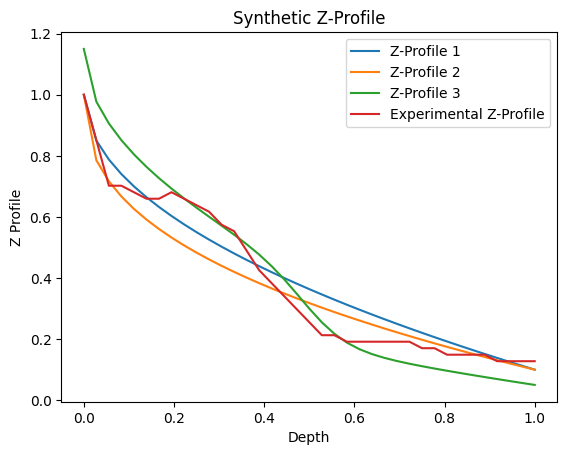

In [170]:
import matplotlib.pyplot as plt
from imaris_ims_file_reader.ims import ims
import tifffile

name = "E-133_S-16_O-1.tif"
input_directory = r"D:\Data Hussein raw\E-133_S-16_O-1"
frame = 16
channel = 2 #crc channel
# image = ims(os.path.join(input_directory, f"{name}.ims"))[frame, channel] 
cropped = tifffile.imread(os.path.join(input_directory, f"{name}"))[14,:,0]
print(cropped.shape)
intensities = []
for z in range(cropped.shape[0]):
    intensities.append(np.percentile(cropped[z], 99))
# remove all values before max of intensities
intensities = intensities[np.argmax(intensities):]

depth = np.linspace(0.0, 1.0, len(intensities), dtype=np.float32)   # 0 = top, 1 = deepest
top, bottom = 1, 0.1
z_profile1 = (top - (top - bottom) * depth**0.5)[:, None, None]
z_profile2 = (top - (top - bottom) * depth**0.4)[:, None, None]

# 1) gentle sqrt falloff (your current curve)
sqrt_part = top - (top - bottom) * np.sqrt(depth)

# 2) sigmoid: slight lift before the knee, bigger drop after
d0, k, deep_drop, boost = 0.5, 20.0, 0.5, 0.15   # +boost = how much higher before the knee
sigmoid = 1.0 / (1.0 + np.exp(-k * (depth - d0)))           # ~0 shallow -> ~1 deep
factor  = (1.0 + boost) - (boost + deep_drop) * sigmoid     # (1+boost) shallow -> (1-deep_drop) deep
z_profile3 = (sqrt_part * factor)[:, None, None]

plt.plot(depth, z_profile1[:, 0, 0], label="Z-Profile 1")
plt.plot(depth, z_profile2[:, 0, 0], label="Z-Profile 2")
plt.plot(depth, z_profile3[:, 0, 0], label="Z-Profile 3")
plt.plot(depth, np.array(intensities) / np.max(intensities), label="Experimental Z-Profile")
plt.xlabel("Depth")
plt.ylabel("Z Profile")
plt.title("Synthetic Z-Profile")
plt.legend()
plt.show()

In [27]:
import numpy as np
from skimage.measure import regionprops

def centroid_accuracy(gt, pred_mask):
    gt = np.asarray(gt)
    pred_mask = np.asarray(pred_mask)
    if gt.shape != pred_mask.shape:
        raise ValueError("Masks must share shape")

    gt_props = regionprops(gt)
    hit_pred_labels = set()
    predicted_labels = np.array([])
    tp = fn = merged_cells = 0

    fn_list = []
    for prop in gt_props:
        centroid = np.rint(prop.centroid).astype(int)
        centroid = tuple(np.clip(centroid, 0, np.array(gt.shape) - 1))
        pred_label = pred_mask[centroid]
        predicted_labels = np.append(predicted_labels, pred_label)
        if pred_label > 0:
            if pred_label in hit_pred_labels:
                # This predicted label has already been matched to a ground truth cell
                fn += 1
                merged_cells += 1
            else:
                tp += 1
                hit_pred_labels.add(int(pred_label))
        else:
            fn += 1
            fn_list.append(int(prop.label))


    pred_labels = set(np.unique(pred_mask))
    pred_labels.discard(0)
    fp = len(pred_labels - hit_pred_labels)
    fp_list = list(pred_labels - hit_pred_labels)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0

    gt_binary = gt > 0
    pred_binary = pred_mask > 0
    intersection = np.count_nonzero(gt_binary & pred_binary)
    dice = (
        (2 * intersection) / (gt_binary.sum() + pred_binary.sum())
        if (gt_binary.sum() + pred_binary.sum())
        else 0.0
    )

    return {
        "true_positives": tp,
        "false_negatives": fn,
        "false_positives": fp,
        "merged_cells": merged_cells,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "voxel_dice": dice,
        "tp_list": list(hit_pred_labels),
        "fp_list": fp_list,
        "fn_list": fn_list,
    }

In [1]:
import segment3D.usegment3d as uSegment3D
import segment3D.parameters as uSegment3D_params

def usegment_stitch(mask):
    """Stitch a stack of 2D XY label masks into a 3D segmentation (no XZ/YZ needed)."""
    labels_xy = np.squeeze(mask).astype(np.int32)

    p = uSegment3D_params.get_2D_to_3D_aggregation_params()
    p['indirect_method']['dtform_method']       = 'edt'   # pure numpy -> no dask cluster / no hang
    # p['postprocess_binary']['binary_fill_holes'] = True
    p['postprocess_binary']['binary_closing']    = 0     # bridge small z-gaps from signal loss
    p['gradient_descent']['do_mp']               = False  # keep gradient descent single-process too
    p['connected_component']['thresh_factor'] = 1   # default 0 -> raise it. Higher threshold on the
                                                  # point-density map => touching centroids separate
    p['connected_component']['smooth_sigma']  = 0   # default 1 -> lower it. Less density smoothing =>
                                                  # adjacent peaks stay distinct instead of fusing

    segmentation3D, (probability3D, gradients3D) = uSegment3D.aggregate_2D_to_3D_segmentation_indirect_method(
        segmentations=[labels_xy, [], []],
        img_xy_shape=labels_xy.shape,
        precomputed_binary=None,
        params=p, savefolder=None, basename=None)
    return segmentation3D

In [135]:
from pathlib import Path
import os
import sys
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
from utils.stitch_3d import stitch_3d
import importlib
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.load_model import load_model
from utils.stitch_3d import stitch_3d
from cellpose import models
from time import time
import tifffile
import numpy as np
import pandas as pd


output_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"
model = load_model(r"C:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\models\2d_low_quality_model")

results = []
for i in range(20):
    # realistic_volume, gt = generate_synthetic_data(number_of_cells = 300, max_attempts = 250, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (420,420,420), organoid_size = 380)
    # print(f"generated {len(np.unique(gt)) - 1} cells in the synthetic organoid")
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid_{i}.tif"), realistic_volume, compression="zlib",
    #     compressionargs={"level": 8})
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_organoid_gt_{i}.tif"), gt.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    gt = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_gt_{i}.tif"))
    realistic_volume = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_{i}.tif"))

    # time_start = time()
    # segmented_2d = segment(realistic_volume, model)
    # time_2d_seg_end = time() 
    # nuclogic_cellpose_time = time_2d_seg_end - time_start

    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_2d_{i}.tif"), segmented_2d.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    segmented_2d = tifffile.imread(os.path.join(output_directory, f"synthetic_segmented_2d_{i}.tif"))
    nuclogic = stitch_3d(segmented_2d, realistic_volume, breaking_threshold = 6, scale=(2.5, 0.64, 0.64))
    time_nuclogic_stitch_end = time()
    # nuclogic_stitch_time = time_nuclogic_stitch_end - time_2d_seg_end
    tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_nuclogic_{i}.tif"), nuclogic.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})

        
    # usegment_start = time()
    # usegment = usegment_stitch(segmented_2d)
    # usegment_end = time()
    # usegment_stitch_time = usegment_end - usegment_start
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_usegment_{i}.tif"), usegment.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    
    # cp4,_,_ = model.eval(
    #                 realistic_volume,
    #                 diameter=None,
    #                 normalize=True,
    #                 flow3D_smooth=0.0,
    #                 resample=True,
    #                 do_3D=True,
    #                 z_axis=0
    #             )
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_cp4_{i}.tif"), cp4.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    # time2 = time()
    # cp4 = tifffile.imread(os.path.join(output_directory, f"synthetic_segmented_cp4_{i}.tif"))
    # np.set_printoptions(suppress=True, precision=4)
    # print(f"Real mask {len(np.unique(gt))-1},NucLogic {len(np.unique(nuclogic))-1}, Cellpose 4 {len(np.unique(cp4))-1}")
    # nuclogic_time = time_nuclogic_stitch_end - time_start
    # cp4_time = time2 - time_nuclogic_stitch_end
    # print(f"NucLogic time: {nuclogic_time:.2f}s, Cellpose 4 time: {cp4_time:.2f}s")
    nuclogic_results = centroid_accuracy(gt, nuclogic)
    # cp4_results = centroid_accuracy(gt, cp4)
    # useg_results = centroid_accuracy(gt, usegment)
    print(f"NucLogic centroid accuracy: {nuclogic_results['f1']:.4f}")
    # print(f"Cellpose 4 centroid accuracy: {cp4_results['f1']:.4f}")
    # print(f"USegment3D centroid accuracy: {useg_results['f1']:.4f}")

    print(f"Nuclogic f1 {nuclogic_results['f1']:.4f}, Cellpose 4 f1 {cp4_results['f1']:.4f}, USegment3D f1 {useg_results['f1']:.4f}")

    # results_df = pd.DataFrame(
    # {
    #     "method": ["nuclogic", "cellpose4", "usegment3d"],
    #     "f1": [nuclogic_results["f1"], cp4_results["f1"], useg_results["f1"]],
    #     "precision": [nuclogic_results["precision"], cp4_results["precision"], useg_results["precision"]],
    #     "recall": [nuclogic_results["recall"], cp4_results["recall"], useg_results["recall"]],
    #     "actual_cells": [len(np.unique(gt)) - 1, len(np.unique(gt)) - 1, len(np.unique(gt)) - 1],
    #     "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1, len(np.unique(usegment)) - 1],
    #     "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"], useg_results["true_positives"]],
    #     "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"], useg_results["false_positives"]],
    #     "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"], useg_results["false_negatives"]],
    #     "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"], useg_results["merged_cells"]],
    #     "total_time": [nuclogic_time, cp4_time, usegment_stitch_time+nuclogic_cellpose_time],
    #     "nuclogic_2d_time": [nuclogic_cellpose_time, 0, nuclogic_cellpose_time],
    #     "stitching_time": [nuclogic_stitch_time, 0, usegment_stitch_time],
    # }
    # )
    results_df = pd.DataFrame(
        {
            "method": ["nuclogic"],
            "f1": [nuclogic_results["f1"]],
            "precision": [nuclogic_results["precision"]],
            "recall": [nuclogic_results["recall"]],
            "actual_cells": [len(np.unique(gt)) - 1],
            "predicted_cells": [len(np.unique(nuclogic)) - 1],
            "true_positives": [nuclogic_results["true_positives"]],
            "false_positives": [nuclogic_results["false_positives"]],
            "false_negatives": [nuclogic_results["false_negatives"]],
            "merged_cells": [nuclogic_results["merged_cells"]],
        }
        )
    name = f"synthetic_organoid_{i}"
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

results_df.to_csv(os.path.join(output_directory, "synthetic_results_nuc.tsv"), sep="\t", index=False)


Using CUDA for processing.
loaded custom model: 2d_low_quality_model
Starting 3D stitching process...
Created 2979 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 288 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 32 breaks.
    Iteration 2: Made 15 breaks.
    Iteration 3: Made 3 breaks.
Finding touching cell pairs...
Found 97 pairs of touching cells.
Splitted 66 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 5 small cells, and removed 22 cells without suitable neighbors.
Final stitched mask has 311 cells.
NucLogic centroid accuracy: 0.9755
Nuclogic f1 0.9755, Cellpose 4 f1 0.9630, USegment3D f1 0.9282
Starting 3D stitching process...
Created 2974 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 285 cells formed.
Starting iterative breaking of cells
    Iteration 1: 

In [4]:
import ssl

_orig = ssl.SSLContext.load_default_certs
def _safe(self, purpose=ssl.Purpose.SERVER_AUTH):
    try: _orig(self, purpose)
    except ssl.SSLError: pass
ssl.SSLContext.load_default_certs = _safe

In [5]:
import skimage.io as skio 
import pylab as plt 
import numpy as np 
import scipy.ndimage as ndimage
import skimage.segmentation as sksegmentation 
import os 
import skimage.exposure as skexposure
import segment3D.parameters as uSegment3D_params # this is useful to call default parameters, and keep track of parameter changes and for saving parameters.  
import segment3D.gpu as uSegment3D_gpu
import segment3D.usegment3d as uSegment3D
import segment3D.filters as uSegment3D_filters 
import segment3D.file_io as uSegment3D_fio

def usegment3D(image, model="nuclei", scale=(2.5, 0.64, 0.64)):
    preprocess_params = uSegment3D_params.get_preprocess_params()
    px_res = scale[1]/scale[0] 
    factor = 0.5 # to resonate with approx 30 diameter in cellpose
    preprocess_params['factor'] = factor # istropic scaling factor 
    preprocess_params['voxel_res'] = [1./px_res, 1., 1.] # scale up 
    img_preprocess = uSegment3D.preprocess_imgs(image, params=preprocess_params)
    img_preprocess = np.squeeze(img_preprocess)
    # img_preprocess = ndimage.median_filter(img_preprocess, size=3)

    cellpose_segment_params = uSegment3D_params.get_Cellpose_autotune_params()
    cellpose_segment_params['cellpose_modelname'] = model # seems to be best model? 
        
    """
    If the below auto-inferred diameter is picking up noise and being too small, we can increase the default ksize, alternatively we can add median_filter.
    """
    cellpose_segment_params['ksize'] = 15
    cellpose_segment_params['best_diam'] = 20

    # invert model
    cellpose_segment_params['model_invert'] = False # new cellpose seems to prefer no model inversion? for membrane markers.
    cellpose_segment_params['use_edge'] = True # for autofinding best slice. 
    print(f"GPU: {cellpose_segment_params['gpu']}")
    if len(img_preprocess.shape) == 3:
        # this expects a multichannel input image and in the format (M,N,L,channels) i.e. channels last.
        img_preprocess = img_preprocess[...,None] # we generate an artificial channel
    #### 1. running for xy orientation. If the savefolder and basename are specified, the output will be saved as .pkl and .mat files 
    img_segment_2D_xy_diams, img_segment_3D_xy_probs, img_segment_2D_xy_flows, img_segment_2D_xy_styles = uSegment3D.Cellpose2D_model_auto(img_preprocess, 
                                                                                                                                            view='xy', 
                                                                                                                                            params=cellpose_segment_params, 
                                                                                                                                            basename=None, savefolder=None)
    # #### 2. running for xz orientation 
    # img_segment_2D_xz_diams, img_segment_3D_xz_probs, img_segment_2D_xz_flows, img_segment_2D_xz_styles = uSegment3D.Cellpose2D_model_auto(img_preprocess, 
    #                                                                                                                                         view='xz', 
    #                                                                                                                                         params=cellpose_segment_params, 
    #                                                                                                                                         basename=None, savefolder=None)

    # #### 3. running for yz orientation 
    # img_segment_2D_yz_diams, img_segment_3D_yz_probs, img_segment_2D_yz_flows, img_segment_2D_yz_styles = uSegment3D.Cellpose2D_model_auto(img_preprocess, 
    #                                                                                                                                         view='yz', 
    #                                                                                                                                         params=cellpose_segment_params, 
    #                                                                                                                                         basename=None, savefolder=None)



    # =============================================================================
    #     3. We can now use the predicted probabilies and flows directly to aggregate a 3D consensus segmentation (Direct Method)
    # =============================================================================

    aggregation_params = uSegment3D_params.get_2D_to_3D_aggregation_params()

    # make sure that we say we are using Cellpose probability predictions which needs to be normalized. If not using Cellpose predicted masks, then set this to be False. We assume this has been appropriately normalized to 0-1
    aggregation_params['combine_cell_probs']['cellpose_prob_mask'] = True 

    # add some temporal decay 
    aggregation_params['gradient_descent']['gradient_decay'] = 0.05 # increase this to alleviate splitting of elongated/branching structures with cellpose gradients or decrease towards 0.0 to encourage splitting. 
    aggregation_params['postprocess_binary']['binary_fill_holes'] = True # we want the base segmentations to have holes filled


    # probs and gradients should be supplied in the order of [xy, xz, yz]. if one or more do not exist use [] e.g. [xy, [], []]
    segmentation3D, (probability3D, gradients3D) = uSegment3D.aggregate_2D_to_3D_segmentation_direct_method(probs=[img_segment_3D_xy_probs,
                                                                                                                    [],
                                                                                                                    []], 
                                                                                                            gradients=[img_segment_2D_xy_flows,
                                                                                                                        [],
                                                                                                                        []], 
                                                                                                            params=aggregation_params,
                                                                                                            savefolder=None,
                                                                                                            basename=None)
    
    postprocess_segment_params = uSegment3D_params.get_postprocess_segmentation_params()
    postprocess_segment_params['flow_consistency']['flow_threshold'] = 0.85 # we can adjust the threshold if needed
    segmentation3D_filt, flow_consistency_intermediates = uSegment3D.postprocess_3D_cell_segmentation(segmentation3D,
                                                                                                      aggregation_params=aggregation_params,
                                                                                                      postprocess_params=postprocess_segment_params,
                                                                                                      cell_gradients=gradients3D,
                                                                                                      savefolder=None,
                                                                                                      basename=None)
    return segmentation3D_filt


In [3]:
# try stardist

import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize

output_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0,1,2)
results = []

for i in range(20):
    # realistic_volume, gt = generate_synthetic_data(number_of_cells = 300, max_attempts = 150, radius_X = 12, radius_Y = 12, radius_Z = 5, randomness = 0.2, vol_shape = (420,420,420), organoid_size = 380)
    realistic_volume = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_{i}.tif"))
    gt = tifffile.imread(os.path.join(output_directory, f"synthetic_organoid_gt_{i}.tif"))
    time_start = time()
    img = normalize(realistic_volume, 1,99.8, axis=axis_norm)
    stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    time_end = time()
    star_time = time_end - time_start
    tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_stardist_{i}.tif"), stardist.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})
    np.set_printoptions(suppress=True, precision=4)
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt, stardist)
    print(f"StarDist3D centroid accuracy: {stardist_results['f1']:.4f}")

    print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

    results_df = pd.DataFrame(
    {
        "method": ["stardist"],
        "f1": [stardist_results["f1"]],
        "precision": [stardist_results["precision"]],
        "recall": [stardist_results["recall"]],
        "actual_cells": [len(np.unique(gt)) - 1],
        "predicted_cells": [len(np.unique(stardist)) - 1],
        "true_positives": [stardist_results["true_positives"]],
        "false_positives": [stardist_results["false_positives"]],
        "false_negatives": [stardist_results["false_negatives"]],
        "merged_cells": [stardist_results["merged_cells"]],
        "total_time": [star_time],
        "nuclogic_2d_time": [0],
        "stitching_time": [0],
    }
    )
    name = f"synthetic_organoid_{i}"
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "synthetic_results_stardist.tsv"), sep="\t", index=False)

Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.


100%|██████████| 32/32 [00:09<00:00,  3.41it/s]


stardist time: 11.08s
StarDist3D centroid accuracy: 0.5795
StarDist3D f1 0.5795


100%|██████████| 32/32 [00:08<00:00,  3.64it/s]


stardist time: 9.90s
StarDist3D centroid accuracy: 0.5536
StarDist3D f1 0.5536


...

stardist time: 10.10s
StarDist3D centroid accuracy: 0.5471
StarDist3D f1 0.5471


100%|██████████| 32/32 [00:09<00:00,  3.55it/s]


stardist time: 10.21s
StarDist3D centroid accuracy: 0.5751
StarDist3D f1 0.5751


100%|██████████| 32/32 [00:09<00:00,  3.53it/s]


stardist time: 10.19s
StarDist3D centroid accuracy: 0.5758
StarDist3D f1 0.5758


<>:62: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:62: SyntaxWarning: "is not" with a literal. Did you mean "!="?
C:\Users\6331823\AppData\Local\Temp\ipykernel_33816\744517341.py:62: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if text is not "ns":


Removing y-tick labels for axis 1
Removing y-tick labels for axis 2
T-test for total_time: t-statistic = -4.4166, p-value = 0.0000


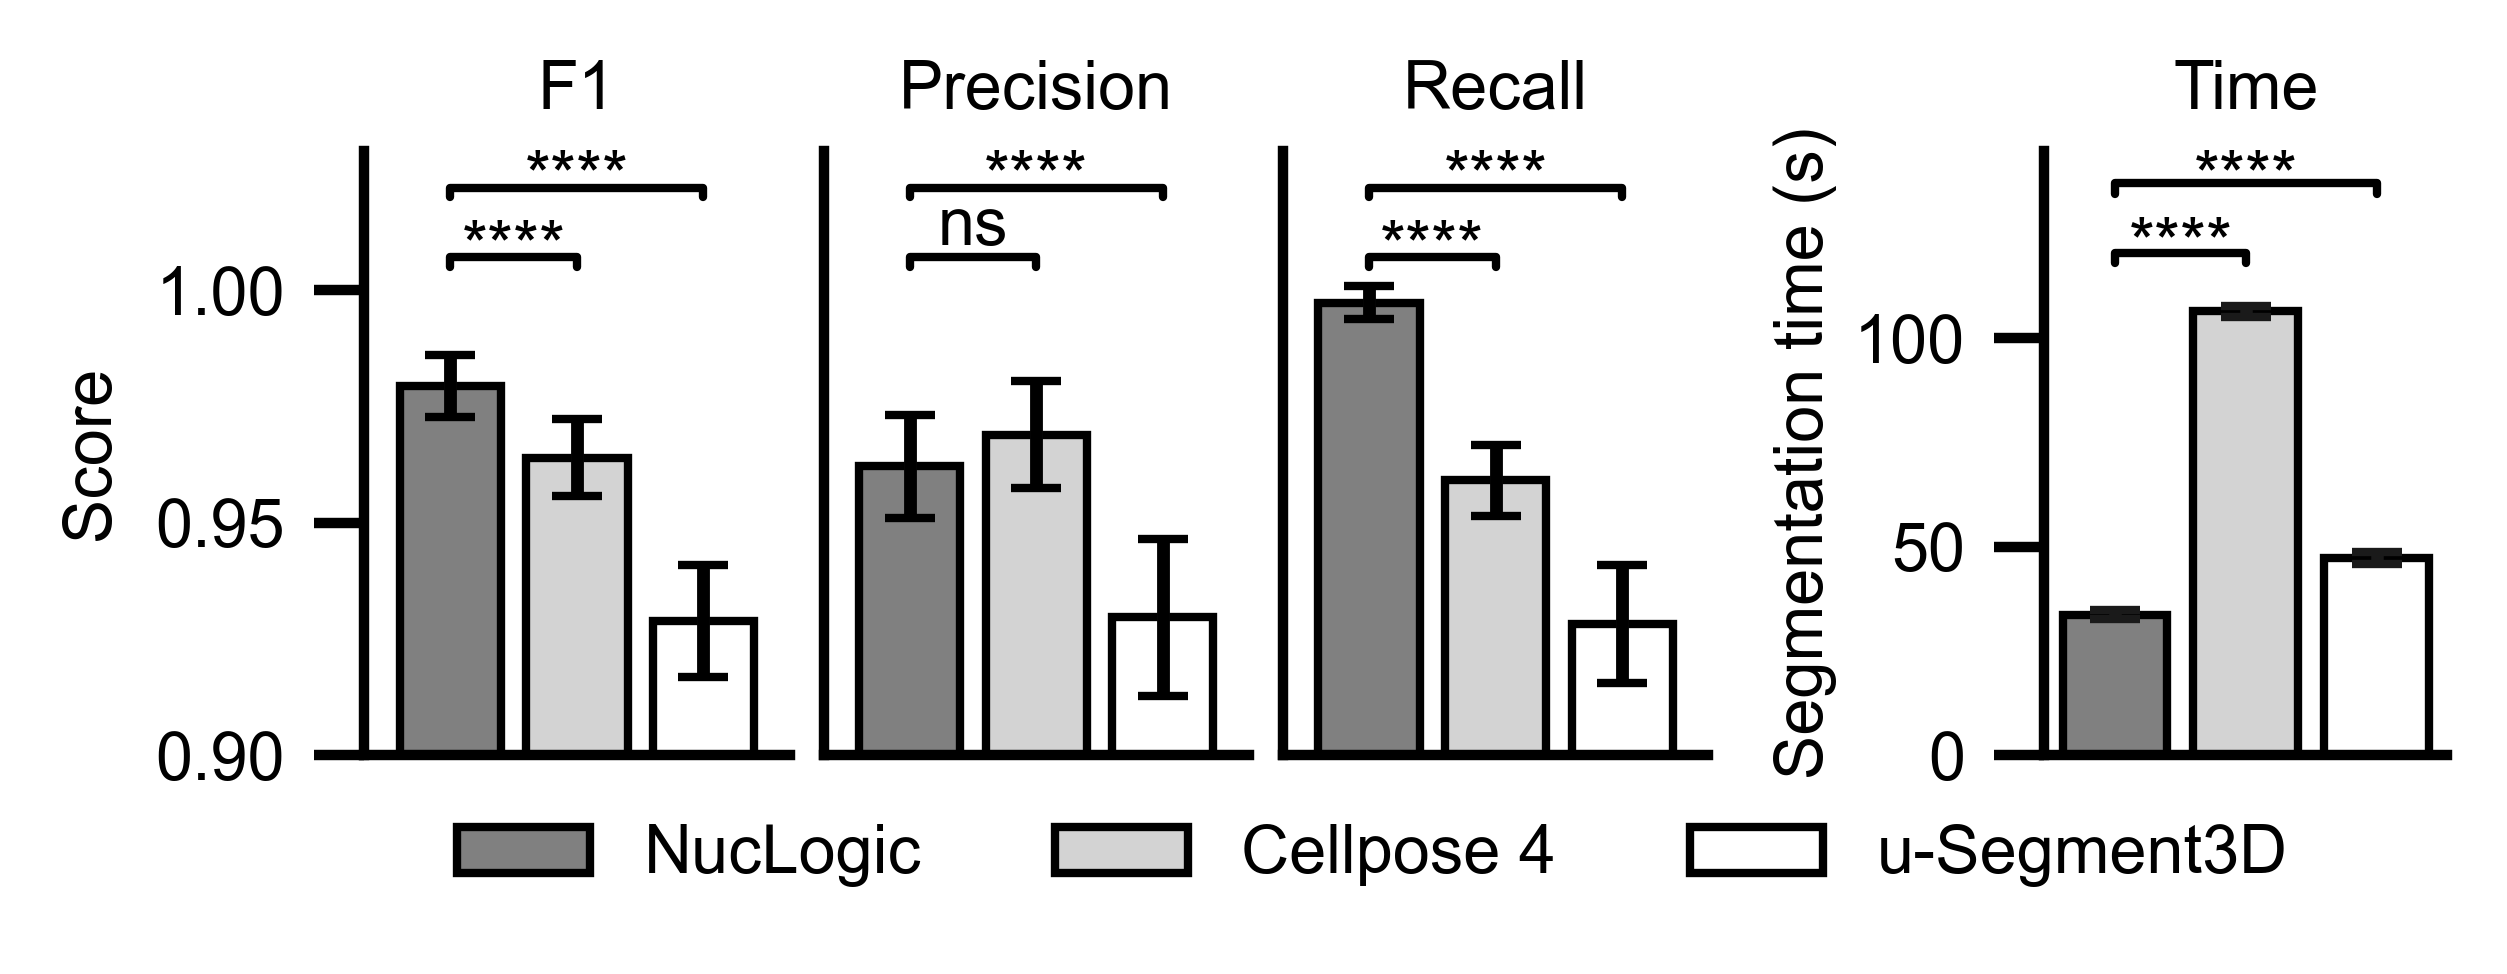

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ttest_ind
from matplotlib.patches import Patch
import os
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "synthetic_results_new.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
score_metrics = ["f1", "precision", "recall"]
time_metric = "total_time"
sns.set_theme(
    style="white",
    context="notebook",
    font="Arial",
    rc={
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
        "text.color":       "black",   # generic text (annotations, legend)
        "axes.labelcolor":  "black",   # x/y axis labels
        "axes.titlecolor":  "black",   # titles
        "xtick.color":      "black",   # x tick MARKS + numbers
        "ytick.color":      "black",   # y tick MARKS + numbers
        "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
    },
)
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)
cols = score_metrics + [time_metric]            
agg = results.groupby("method")[cols].agg(["mean", "std"])

method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
legend_handles = [
    Patch(facecolor=method_colors[m], edgecolor="black", label=m)
    for m in methods
]

def significance_text(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
def add_bracket(ax, x1, x2, y, text, dh=0.03, barh=0.01):
    ax.plot([x1, x1, x2, x2], [y, y + barh*y, y + barh*y, y], color="black", lw=1)
    if text is not "ns":
        ax.text((x1 + x2) / 2, y + barh - dh*y, text, ha="center", va="bottom", fontsize=8)
    else:
        ax.text((x1 + x2) / 2, y + barh, text, ha="center", va="bottom", fontsize=8)

fig = plt.figure(figsize=(5.6*0.8, 2*0.8), dpi=600)
outer = fig.add_gridspec(1, 3, width_ratios=[3.0, 0.75, 0.9], wspace=0.0)

left = outer[0].subgridspec(1, 3, wspace=0.08)
axes = [fig.add_subplot(left[0, i]) for i in range(3)]

spacer = fig.add_subplot(outer[1])
spacer.axis("off")

time_ax = fig.add_subplot(outer[2])
axes.append(time_ax)

# --- 3 score bars on the LEFT axis ---
for i, metric in enumerate(score_metrics):
    means = [agg.loc[m, (metric, "mean")] for m in methods]
    sds   = [agg.loc[m, (metric, "std")]  for m in methods]

    # perform t test to check if the difference between the two methods is significant
    p_cp4 = ttest_ind(
        results[results["method"] == "NucLogic"][metric],
        results[results["method"] == "Cellpose 4"][metric],
        equal_var=False,
    ).pvalue

    p_useg = ttest_ind(
            results[results["method"] == "NucLogic"][metric],
            results[results["method"] == "u-Segment3D"][metric],
            equal_var=False,
    ).pvalue
    reject, p_adj, _, _ = multipletests([p_cp4, p_useg], alpha=0.05, method="holm")
    p_cp4_adj, p_useg_adj = p_adj
    fillcolor = [method_colors[m] for m in methods]
    axes[i].bar(methods, means, yerr=sds, linewidth=1,
           label=metric.capitalize(), color=fillcolor, edgecolor="black")
    

    max_height = 1.005
    add_bracket(axes[i], 0, 1, max_height, significance_text(p_cp4_adj), dh=0.005, barh=0.002)
    add_bracket(axes[i], 0, 2, max_height + 0.015, significance_text(p_useg_adj), dh=0.005, barh=0.002)
        
    axes[i].set_ylim(0.9, 1.03)
    axes[i].set_ylabel("")
    axes[i].set_title(metric.capitalize(), pad=5)
    axes[i].errorbar(x=methods, y=means, yerr=sds, fmt='none', color="black", capsize=3)
    axes[i].margins(x=0.1)

    if i != 0:
        print(f"Removing y-tick labels for axis {i}")
        axes[i].set_yticklabels("")
        # axes[i].tick_params(left=True, bottom=False)
    else:
        axes[i].set_ylabel("Score")
        axes[i].tick_params(left=True, bottom=False)


# --- cosmetics ---
for ax in axes:
    ax.tick_params(axis="x", labelbottom=False, bottom=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

time_ax.set_ylabel("Segmentation time (s)", labelpad=2) #can adjust labelpad
time_ax.yaxis.set_label_position("left")
time_ax.yaxis.tick_left()
time_ax.tick_params(left=True, labelleft=True, right=False, labelright=False)
means = [agg.loc[m, (time_metric, "mean")] for m in methods]
sds   = [agg.loc[m, (time_metric, "std")]  for m in methods]
p_cp4 = ttest_ind(
    results[results["method"] == "NucLogic"][metric],
    results[results["method"] == "Cellpose 4"][metric],
    equal_var=False,
).pvalue

p_useg = ttest_ind(
        results[results["method"] == "NucLogic"][metric],
        results[results["method"] == "u-Segment3D"][metric],
        equal_var=False,
).pvalue
reject, p_adj, _, _ = multipletests([p_cp4, p_useg], alpha=0.05, method="holm")
p_cp4_adj, p_useg_adj = p_adj
print(f"T-test for {time_metric}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
fillcolor = [method_colors[m] for m in methods]
axes[3].bar(methods, means, yerr=sds, linewidth=1, capsize=3,
        label=metric.capitalize(), color=fillcolor, edgecolor="black")

max_height = 118
add_bracket(axes[3], 0, 1, max_height, significance_text(p_cp4_adj), barh=0.02)
add_bracket(axes[3], 0, 2, max_height*1.14, significance_text(p_useg_adj), barh=0.02)

axes[3].set_ylim(0, 145)
axes[3].set_title("Time", pad=5)

fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.05))
fig.subplots_adjust(bottom=0.25)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
# plt.savefig(os.path.join(figure_folder, "synthetic_results_scores_all.eps"), dpi=600, bbox_inches="tight")
plt.show()

Figure 2D

In [9]:
import napari
import sys
import os
from napari.utils.colormaps import colormap_utils as cu
import tifffile
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.centroid_accuracy import centroid_accuracy

colormap = cu.label_colormap(num_colors=1024)
colormap_seg = {0: '', 1: "#65ae45", 2: 'cyan', 3: 'magenta'}

def color_mask(mask, gt):
    results = centroid_accuracy(gt, mask)
    tp_list = results["tp_list"]
    print(f"True positives: {len(tp_list)}")
    fp_list = results["fp_list"]
    fn_list = results["fn_list"]
    # mask-based classes (tp=1, fp=2)
    lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
    lut[np.asarray(tp_list, dtype=int)] = 1
    lut[np.asarray(fp_list, dtype=int)] = 2
    colored = lut[mask]

    # fn comes from gt, painted on top
    fn_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
    fn_lut[np.asarray(fn_list, dtype=int)] = 3
    colored[fn_lut[gt] == 3] = 3
    return colored

input_directory = r"C:\Users\6331823\Local SSD\NucLogic paper figure data\Synthethic data"

organoid_number = 3
realistic_volume = tifffile.imread(os.path.join(input_directory, f"synthetic_organoid_{organoid_number}.tif"))
gt = tifffile.imread(os.path.join(input_directory, f"synthetic_organoid_gt_{organoid_number}.tif"))
nuclogic = tifffile.imread(os.path.join(input_directory, f"synthetic_segmented_nuclogic_{organoid_number}.tif"))
nuclogic = color_mask(nuclogic, gt)
cp4 = tifffile.imread(os.path.join(input_directory, f"synthetic_segmented_cp4_{organoid_number}.tif"))
cp4 = color_mask(cp4, gt)
usegment = tifffile.imread(os.path.join(input_directory, f"synthetic_segmented_usegment_{organoid_number}.tif"))
usegment = color_mask(usegment, gt)
viewer = napari.Viewer(ndisplay=3)
scale = (2.5, 0.64, 0.64)

y_half = slice(0, realistic_volume.shape[1] // 2)
x_half = slice(0, realistic_volume.shape[2])

contrast = (np.median(realistic_volume) * 0.8, np.percentile(realistic_volume, 99.98))
viewer.add_image(realistic_volume[:, y_half, x_half], scale = scale, contrast_limits = contrast, colormap="Greys")
# viewer.add_labels(gt[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.add_labels(cp4[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.add_labels(usegment[:, y_half, x_half], scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
viewer.theme = 'light'

# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "synthetic_data_colored.png"), canvas_only=True, scale = 4)

# add top slice
# set ndisplay to 2d
# viewer = napari.Viewer(ndisplay=2)
# viewer.add_image(realistic_volume, scale = scale, contrast_limits = (100, 115), colormap="Greys")
# viewer.add_labels(nuclogic, scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
# viewer.add_labels(cp4, scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
# viewer.add_labels(usegment, scale = scale, iso_gradient_mode="smooth", colormap=colormap_seg, opacity=1)
# # viewer.reset_view()
# # set z slice to top
# viewer.dims.set_point(0, realistic_volume.shape[0] - 1)
# viewer.dims.current_step = (101, 0, 0)
# viewer.scale_bar.visible = True
# viewer.scale_bar.unit = 'µm'
# #toggle grid mode on
# viewer.grid.enabled = True
# viewer.theme = 'light'
# napari.run()

# output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
# viewer.screenshot(path=os.path.join(output_directory, "synthetic_data_slice.png"), canvas_only=True, scale = 2)


True positives: 300
True positives: 287
True positives: 277


c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(
c:\Users\6331823\AppData\Local\anaconda3\envs\organoid_segmenter\Lib\site-packages\napari\utils\colormaps\colormap.py:455: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

Test on drosophila

In [35]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import tifffile
import pandas as pd

names = ["Drosophila_1", "Drosophila_2"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

scale = (1, 1, 1)

# model = load_model(r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Drosophila_1\model\drosophila")
# model = load_model(
#     r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
# )

results = []
for name in names:
    input_directory = os.path.join(base_directory, name)

    image = tifffile.imread(os.path.join(input_directory, "data.tif"))

    # start_time = time.time()
    # mask = segment(image, model)
    # tifffile.imwrite(
    #     os.path.join(input_directory, "2d_segmented_seg4.tif"),
    #     mask,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_trained.tif"))
    # segmentation_time = time.time() - start_time


    # start_stitch_time = time.time()
    # nuclogic = stitch_3d(
    #     mask,
    #     image,
    #     image_type_1="wt",
    #     breaking_threshold=6,
    #     scale=scale
    # )
    # end_time = time.time()
    # nuclogic_time = end_time - start_time
    # nuclogic_cellpose_time = start_stitch_time - start_time
    # nuclogic_stitch_time = end_time - start_stitch_time
    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_nuclogic_seg4.tif"),
    #     nuclogic,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    ground_truth = tifffile.imread(
        os.path.join(input_directory, "GroundTruth.tif")
    )

    # nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    # print(f"centroid accuracy: {nuclogic_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    # )

    # print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    # print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    # print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")

    usegment_start = time.time()
    usegment = usegment_stitch(mask)
    usegment_end = time.time()
    usegment_results = (centroid_accuracy(ground_truth, usegment))
    print(f"centroid accuracy: {usegment_results}")
    print(usegment_end - usegment_start)

    # start_cp4 = time.time()
    # cp4,_,_ = model.eval(
    #                 image,
    #                 diameter=None,
    #                 normalize=True,
    #                 flow3D_smooth=0.4,
    #                 invert=False,
    #                 resample=True,
    #                 do_3D=True,
    #                 z_axis=0
    #             )
    # end_cp4 = time.time()
    # cp4_time = end_cp4 - start_cp4

    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_cp4.tif"),
    #     cp4,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )

    # cp4_results = (centroid_accuracy(ground_truth, cp4))
    # print(f"centroid accuracy: {cp4_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    # )
    # print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    # print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # # save results of centroid accuracy and amount of cells to a tsv file

#     results_df = pd.DataFrame(
#         {
#             "method": ["nuclogic", "cellpose4"],
#             "f1": [nuclogic_results["f1"], cp4_results["f1"]],
#             "precision": [nuclogic_results["precision"], cp4_results["precision"]],
#             "recall": [nuclogic_results["recall"], cp4_results["recall"]],
#             "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
#             "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
#             "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
#             "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
#             "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
#             "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
#             "total_time": [nuclogic_time, cp4_time],
#             "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
#             "stitching_time": [nuclogic_stitch_time, 0],
#         }
#     )
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "zebrafish_results_seg4.tsv"), sep="\t", index=False)

centroid accuracy: {'true_positives': 476, 'false_negatives': 14, 'false_positives': 19, 'merged_cells': 0, 'precision': 0.9616161616161616, 'recall': 0.9714285714285714, 'f1': 0.966497461928934, 'voxel_dice': 0.7830214615947255, 'tp_list': [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 145, 146, 147, 148, 149, 150, 152, 153, 154, 155, 156, 157, 158, 159, 160, 163, 164, 165, 166, 167, 168, 169, 171, 172, 173, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188,

100%|██████████| 200/200 [01:18<00:00,  2.55it/s]


centroid accuracy: {'true_positives': 1582, 'false_negatives': 112, 'false_positives': 404, 'merged_cells': 96, 'precision': 0.796576032225579, 'recall': 0.9338842975206612, 'f1': 0.8597826086956522, 'voxel_dice': 0.8880406428464008, 'tp_list': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 88, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 103, 104, 105, 108, 109, 110, 111, 112, 113, 115, 116, 119, 120, 121, 122, 125, 126, 127, 128, 129, 130, 131, 133, 134, 136, 138, 139, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 155, 157, 159, 162, 164, 165, 166, 167, 168, 169, 170, 172, 173, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 194, 195, 197, 198, 200, 201, 202, 2

100%|██████████| 200/200 [00:40<00:00,  4.93it/s]


centroid accuracy: {'true_positives': 482, 'false_negatives': 8, 'false_positives': 13, 'merged_cells': 1, 'precision': 0.9737373737373738, 'recall': 0.9836734693877551, 'f1': 0.9786802030456854, 'voxel_dice': 0.8610440991431632, 'tp_list': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176,

In [5]:
# drosophila stardist
# try stardist

import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize

names = ["Drosophila_1", "Drosophila_2"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0,1,2)
results = []

for name in names:
    input_directory = os.path.join(base_directory, name)
    image = tifffile.imread(os.path.join(input_directory, "data.tif"))
    gt = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))    
    # time_start = time()
    # img = normalize(image, 1,99.8, axis=axis_norm)
    # stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    # time_end = time()
    # star_time = time_end - time_start
    # tifffile.imwrite(os.path.join(output_directory, f"synthetic_segmented_stardist_{name}.tif"), stardist.astype(np.uint16), compression="zlib",
    #     compressionargs={"level": 8})
    stardist = tifffile.imread(os.path.join(input_directory, f"3d_segmented_stardist_{name}.tif"))
    np.set_printoptions(suppress=True, precision=4)
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt, stardist)
    print(f"StarDist3D centroid accuracy: {stardist_results}")

#     print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

#     results_df = pd.DataFrame(
#     {
#         "method": ["stardist"],
#         "f1": [stardist_results["f1"]],
#         "precision": [stardist_results["precision"]],
#         "recall": [stardist_results["recall"]],
#         "actual_cells": [len(np.unique(gt)) - 1],
#         "predicted_cells": [len(np.unique(stardist)) - 1],
#         "true_positives": [stardist_results["true_positives"]],
#         "false_positives": [stardist_results["false_positives"]],
#         "false_negatives": [stardist_results["false_negatives"]],
#         "merged_cells": [stardist_results["merged_cells"]],
#         "total_time": [star_time],
#         "nuclogic_2d_time": [0],
#         "stitching_time": [0],
#     }
#     )
#     name = f"synthetic_organoid_{i}"
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "synthetic_results_stardist.tsv"), sep="\t", index=False)

Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.
stardist time: 236.04s
StarDist3D centroid accuracy: {'true_positives': 1104, 'false_negatives': 590, 'false_positives': 213, 'merged_cells': 2, 'precision': 0.8382687927107062, 'recall': 0.6517119244391971, 'f1': 0.7333111922949187, 'voxel_dice': 0.50332259495602, 'tp_list': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 34, 35, 37, 38, 39, 40, 41, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 56, 57, 60, 63, 64, 65, 66, 67, 68, 69, 70, 73, 74, 76, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 1

In [ ]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)

names = ["Drosophila_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
dir = os.path.join(base_directory, names[0])
image = tifffile.imread(os.path.join(dir, "data.tif"))
ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))
viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)

viewer.reset_view()
viewing_angle = (0, 180, 90)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
viewer.screenshot(path=os.path.join(output_directory, "drosophila_data.png"), canvas_only=True, scale = 2.2)

# Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (109.09719441054212, 99.90710855199106, 302.3227946123624)
viewer.camera.zoom   = 11.503409054721994
# @viewer.bind_key('c')  # press 'c' to capture camera state
# def print_camera(viewer):
#     print(f"viewer.camera.center = {viewer.camera.center}")
#     print(f"viewer.camera.angles = {viewer.camera.angles}")
#     print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "drosophila_zoomed.png"), canvas_only=True, scale = 2)

NameError: name 'os' is not defined

CP4 T-test for f1: t-statistic = -1.4986, p-value = 0.3694
Useg T-test for f1: t-statistic = 0.9161, p-value = 0.5239
CP4 T-test for total_time: t-statistic = -16.3746, p-value = 0.0315
Useg T-test for total_time: t-statistic = -4.4166, p-value = 0.1365


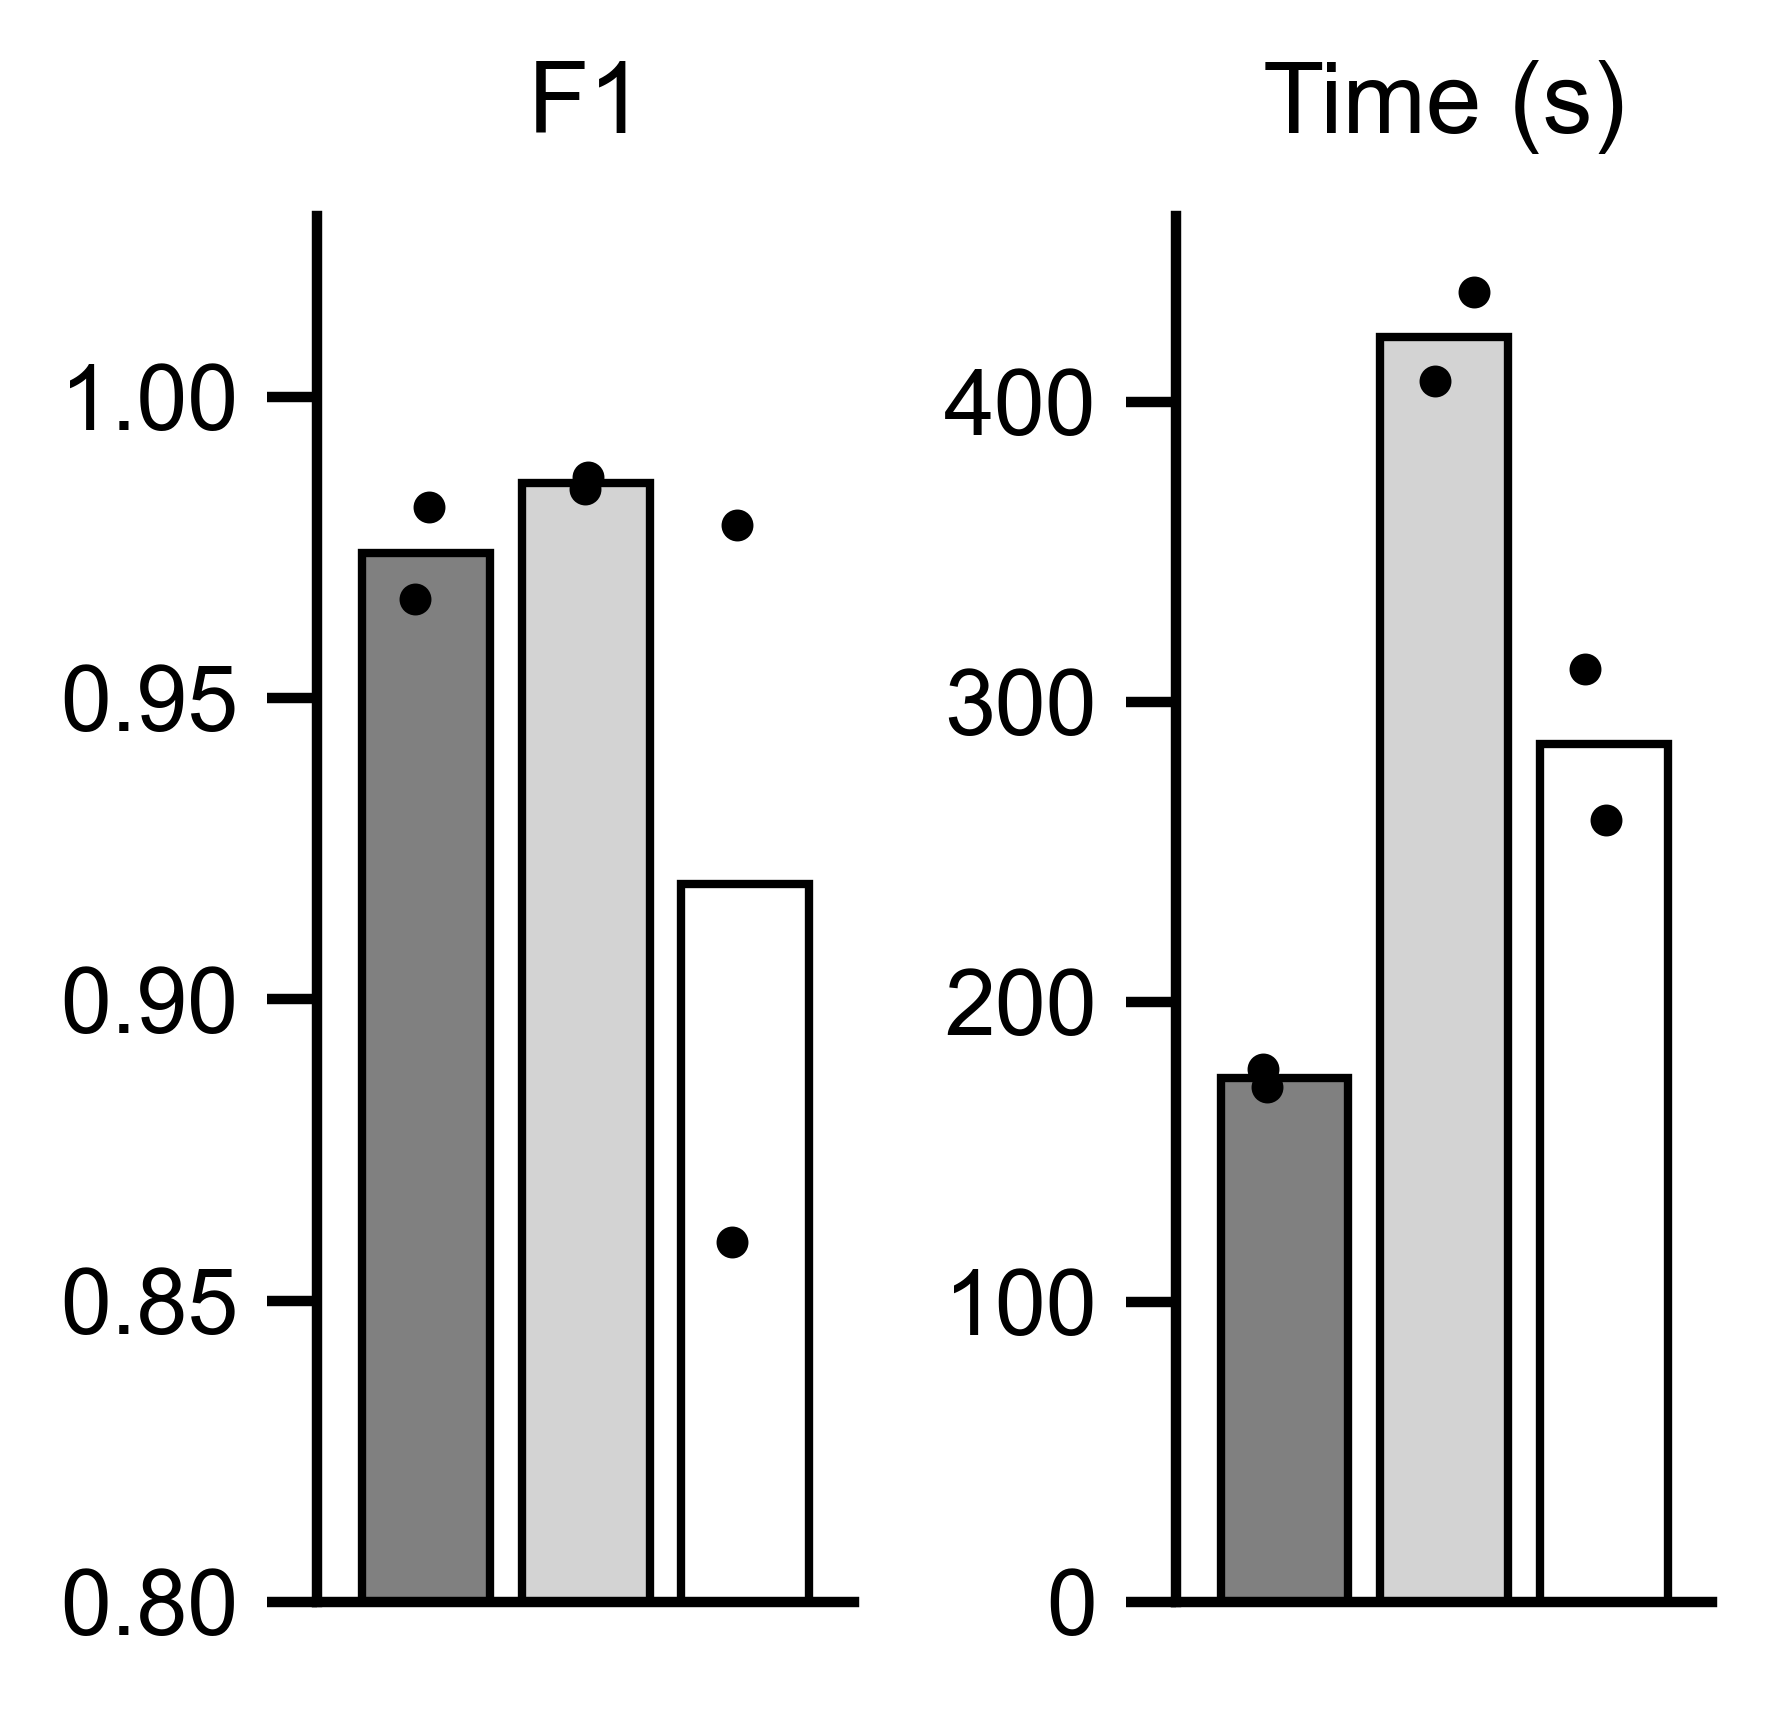

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "drosophila_results.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
metrics = ["f1", "total_time"]
method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)                    
agg = results.groupby("method")[metrics].agg(["mean", "std"])

x = np.arange(len(methods))          # one group center per method
color =  "black"

fig, axes = plt.subplots(
    figsize=(3, 3),
    dpi=600,
    ncols=2,
    gridspec_kw={"width_ratios": [1,1], "wspace": 0.6},
)


for i, metric in enumerate(metrics):
        means = [agg.loc[m, (metric, "mean")] for m in methods]
        sds   = [agg.loc[m, (metric, "std")]  for m in methods]
        axes[i].bar(x=methods, height=means, capsize=4, linewidth=1,
                label="Time", color=[method_colors[m] for m in methods], edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars
        # axes[i].errorbar(x=methods, y=means, yerr=sds, fmt='none', color="black", capsize=4)
        for j, method in enumerate(methods):
                vals = results.loc[results["method"] == method, metric].to_numpy()
                jitter = np.random.normal(loc=0, scale=0.1, size=len(vals))
                axes[i].scatter(
                        np.full(len(vals), x[j]) + jitter,
                        vals,
                        color="black",
                        s=8,
                        zorder=3,
                )

        axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        axes[i].set_xticklabels("")
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)

        axes[i].tick_params(left=True, bottom=False) 
        axes[i].tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
        axes[i].margins(x=0.1)
        axes[i].set_ylabel("")

        nuclogic_values = results[results["method"] == "NucLogic"][metric]
        cellpose_values = results[results["method"] == "Cellpose 4"][metric]
        usegment_values = results[results["method"] == "u-Segment3D"][metric]
        star_values = results[results["method"] == "StarDist"][metric]
     
        if i == 0:
                axes[i].set_title("F1", pad=10)
                axes[i].set_ylim(0.8, 1.03)
        else:
                axes[i].set_title("Time (s)", pad=10)
                axes[i].set_ylim(0, 462)



figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "drosophila_results_full.eps"), dpi=600, bbox_inches="tight")
plt.show()

Zebrafish

In [31]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import tifffile
import pandas as pd

# names = ["Drosophila_1", "Drosophila_2"]
names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

model = load_model(
    r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D\Zebrafish_1\model\models\zebrafish"
)
# model = load_model(
#     r"C:\Users\6331823\Local SSD\Train model cell segmentation\models\cell_segmentation_4"
# )

results = []
for name in names:
    if name == "Zebrafish_1":
        scale = (2.5, 0.43, 0.43)

    input_directory = os.path.join(base_directory, name)

    image = tifffile.imread(os.path.join(input_directory, "data.tif"))

    # start_time = time.time()
    # mask = segment(image, model)
    # tifffile.imwrite(
    #     os.path.join(input_directory, "2d_segmented_trained.tif"),
    #     mask,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_trained.tif"))
    # segmentation_time = time.time() - start_time


    # start_stitch_time = time.time()
    # nuclogic = stitch_3d(
    #     mask,
    #     image,
    #     image_type_1="wt",
    #     breaking_threshold=6,
    #     scale=scale
    # )
    # end_time = time.time()
    # nuclogic_time = end_time - start_time
    # nuclogic_cellpose_time = start_stitch_time - start_time
    # nuclogic_stitch_time = end_time - start_stitch_time
    # tifffile.imwrite(
    #     os.path.join(input_directory, "3d_segmented_nuclogic_trained.tif"),
    #     nuclogic,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    # nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_trained.tif"))

    ground_truth = tifffile.imread(
        os.path.join(input_directory, "GroundTruth.tif")
    )

    # nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    # print(f"centroid accuracy: {nuclogic_results}")
    # print(
    #     f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    # )

    # print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    # print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    # print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")

    print("Running u-Segment3D...")
    usegment_start = time.time()
    usegment = usegment_stitch(mask)
    usegment_end = time.time()
    usegment_time = usegment_end - usegment_start
    usegment_results = (centroid_accuracy(ground_truth, usegment))
    print(f"centroid accuracy: {usegment_results}")
    print(f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(usegment)) - 1}")
    print(f"u-Segment3D completed in {usegment_time:.2f} seconds.")

#     start_cp4 = time.time()
#     cp4,_,_ = model.eval(
#                     image,
#                     diameter=None,
#                     normalize=True,
#                     flow3D_smooth=0.4,
#                     invert=False,
#                     resample=True,
#                     do_3D=True,
#                     z_axis=0,
#                     min_size=150,
#                 )
#     end_cp4 = time.time()
#     cp4_time = end_cp4 - start_cp4

#     tifffile.imwrite(
#         os.path.join(input_directory, "3d_segmented_cp4_trained.tif"),
#         cp4,
#         compression="zlib",
#         compressionargs={"level": 8},
#     )

#     cp4_results = (centroid_accuracy(ground_truth, cp4))
#     print(f"centroid accuracy: {cp4_results}")
#     print(
#         f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
#     )
#     print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
#     print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

#     # save results of centroid accuracy and amount of cells to a tsv file

#     results_df = pd.DataFrame(
#         {
#             "method": ["nuclogic", "cellpose4"],
#             "f1": [nuclogic_results["f1"], cp4_results["f1"]],
#             "precision": [nuclogic_results["precision"], cp4_results["precision"]],
#             "recall": [nuclogic_results["recall"], cp4_results["recall"]],
#             "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
#             "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
#             "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
#             "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
#             "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
#             "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
#             "total_time": [nuclogic_time, cp4_time],
#             "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
#             "stitching_time": [nuclogic_stitch_time, 0],
#         }
#     )
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "zebrafish_results_trained.tsv"), sep="\t", index=False)

Using CUDA for processing.
loaded custom model: zebrafish
Automatric binary thresholding:  0.5


100%|██████████| 200/200 [03:48<00:00,  1.14s/it]


centroid accuracy: {'true_positives': 10323, 'false_negatives': 2470, 'false_positives': 2717, 'merged_cells': 1940, 'precision': 0.7916411042944785, 'recall': 0.8069256624716642, 'f1': 0.7992103123911277, 'voxel_dice': 0.8300334072053984, 'tp_list': [1, 2, 3, 4, 5, 7, 9, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 24, 26, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 41, 44, 45, 46, 47, 50, 51, 52, 53, 54, 55, 56, 57, 58, 61, 62, 63, 64, 66, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 86, 88, 89, 90, 91, 94, 95, 96, 97, 98, 99, 102, 103, 104, 105, 107, 109, 110, 111, 112, 115, 116, 117, 119, 121, 123, 124, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 148, 149, 150, 151, 152, 154, 155, 156, 157, 158, 162, 163, 164, 165, 166, 167, 168, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 182, 183, 184, 185, 186, 187, 189, 190, 191, 192, 193, 194, 195, 196, 197, 199, 200, 201, 204, 205, 206, 207, 208, 209, 210

In [5]:
# try stardist zebrafish

import os
import sys
from time import time
import tifffile
import numpy as np
import pandas as pd
from stardist.models import StarDist3D
from csbdeep.utils import normalize
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.centroid_accuracy import centroid_accuracy

names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"

print("Loading pretrained StarDist3D model...")
model = StarDist3D.from_pretrained('3D_demo')
axis_norm = (0,1,2)
results = []

for name in names:
    input_directory = os.path.join(base_directory, name)
    image = tifffile.imread(os.path.join(input_directory, "data.tif"))
    gt = tifffile.imread(os.path.join(input_directory, "GroundTruth.tif"))    
    time_start = time()
    img = normalize(image, 1,99.8, axis=axis_norm)
    stardist, details = model.predict_instances(img, n_tiles=model._guess_n_tiles(img))
    time_end = time()
    star_time = time_end - time_start
    tifffile.imwrite(os.path.join(input_directory, f"3d_segmented_stardist_{name}.tif"), stardist.astype(np.uint16), compression="zlib",
        compressionargs={"level": 8})
    stardist = tifffile.imread(os.path.join(input_directory, f"3d_segmented_stardist_{name}.tif"))
    np.set_printoptions(suppress=True, precision=4)
    print(f"stardist time: {star_time:.2f}s")
    stardist_results = centroid_accuracy(gt, stardist)
    print(f"StarDist3D centroid accuracy: {stardist_results}")

#     print(f"StarDist3D f1 {stardist_results['f1']:.4f}")

#     results_df = pd.DataFrame(
#     {
#         "method": ["stardist"],
#         "f1": [stardist_results["f1"]],
#         "precision": [stardist_results["precision"]],
#         "recall": [stardist_results["recall"]],
#         "actual_cells": [len(np.unique(gt)) - 1],
#         "predicted_cells": [len(np.unique(stardist)) - 1],
#         "true_positives": [stardist_results["true_positives"]],
#         "false_positives": [stardist_results["false_positives"]],
#         "false_negatives": [stardist_results["false_negatives"]],
#         "merged_cells": [stardist_results["merged_cells"]],
#         "total_time": [star_time],
#         "nuclogic_2d_time": [0],
#         "stitching_time": [0],
#     }
#     )
#     name = f"synthetic_organoid_{i}"
#     results_df.insert(0, "sample", name) 
#     results.append(results_df)
# results_df = pd.concat(results, ignore_index=True)

# results_df.to_csv(os.path.join(output_directory, "synthetic_results_stardist.tsv"), sep="\t", index=False)

Loading pretrained StarDist3D model...
Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.


100%|██████████| 768/768 [12:16<00:00,  1.04it/s]


stardist time: 809.41s
StarDist3D centroid accuracy: {'true_positives': 4821, 'false_negatives': 7972, 'false_positives': 2752, 'merged_cells': 52, 'precision': 0.6366037237554469, 'recall': 0.37684671304619716, 'f1': 0.4734361190218992, 'voxel_dice': 0.3718252077811998, 'tp_list': [1, 3, 4, 5, 6, 7, 8, 9, 11, 14, 16, 19, 21, 24, 32, 35, 36, 37, 41, 43, 44, 46, 48, 49, 50, 53, 55, 56, 58, 60, 61, 63, 64, 65, 69, 71, 72, 74, 82, 89, 94, 95, 99, 101, 102, 104, 106, 107, 109, 110, 112, 113, 116, 117, 119, 120, 123, 125, 128, 130, 131, 133, 135, 138, 139, 143, 144, 145, 147, 148, 151, 152, 154, 155, 156, 157, 158, 159, 160, 161, 164, 165, 166, 167, 169, 171, 172, 173, 175, 176, 177, 178, 179, 180, 184, 185, 187, 188, 189, 190, 191, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 211, 212, 214, 216, 217, 218, 220, 223, 225, 229, 230, 231, 232, 233, 234, 235, 237, 240, 241, 242, 243, 244, 248, 249, 250, 251, 253, 254, 256, 257, 258, 259, 260, 261, 263, 265, 26

In [13]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)
colormap_seg = {0: '', 1: 'green', 2: 'magenta', 3: 'cyan'}

names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
dir = os.path.join(base_directory, names[0])
image = tifffile.imread(os.path.join(dir, "data.tif"))
ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))

# def color_mask(mask, gt, tp_list, fp_list, fn_list):
#     # mask-based classes (tp=1, fp=2)
#     lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
#     lut[np.asarray(tp_list, dtype=int)] = 1
#     lut[np.asarray(fp_list, dtype=int)] = 2
#     colored = lut[mask]

#     # fn comes from gt, painted on top
#     fn_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
#     fn_lut[np.asarray(fn_list, dtype=int)] = 3
#     colored[fn_lut[gt] == 3] = 3
#     return colored

# nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
# nuclogic_colored = color_mask(nuclogic, ground_truth, nuclogic_results["tp_list"], nuclogic_results["fp_list"], nuclogic_results["fn_list"])
# cp4_results = (centroid_accuracy(ground_truth, cp4))
# cp4_colored = color_mask(cp4, ground_truth, cp4_results["tp_list"], cp4_results["fp_list"], cp4_results["fn_list"])

viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "zebrafish_data.png"), size=(2160, 3840), canvas_only=True, scale = 1.2)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (24.796264343669097, 237.4340231835281, 402.7615460461847)
viewer.camera.angles = (179.77222044782297, -0.3018545374737001, 1.8301771723984743)
viewer.camera.zoom   = 10.457644595201812
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "zebrafish_zoomed.png"), size=(2160, 3840), canvas_only=True, scale = 1.3)

array([[[110, 110, 110, 255],
        [109, 109, 109, 255],
        [107, 107, 107, 255],
        ...,
        [121, 187, 216, 255],
        [121, 187, 216, 255],
        [121, 187, 216, 255]],

       [[110, 110, 110, 255],
        [108, 108, 108, 255],
        [106, 106, 106, 255],
        ...,
        [121, 187, 216, 255],
        [121, 187, 216, 255],
        [121, 187, 216, 255]],

       [[109, 109, 109, 255],
        [108, 108, 108, 255],
        [106, 106, 106, 255],
        ...,
        [121, 187, 216, 255],
        [121, 187, 216, 255],
        [121, 187, 216, 255]],

       ...,

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        ...,
        [  0,   0,   0, 255],
        [  0,   0,   0, 255],
        [  0,   0,   0, 255]],

       [[  0

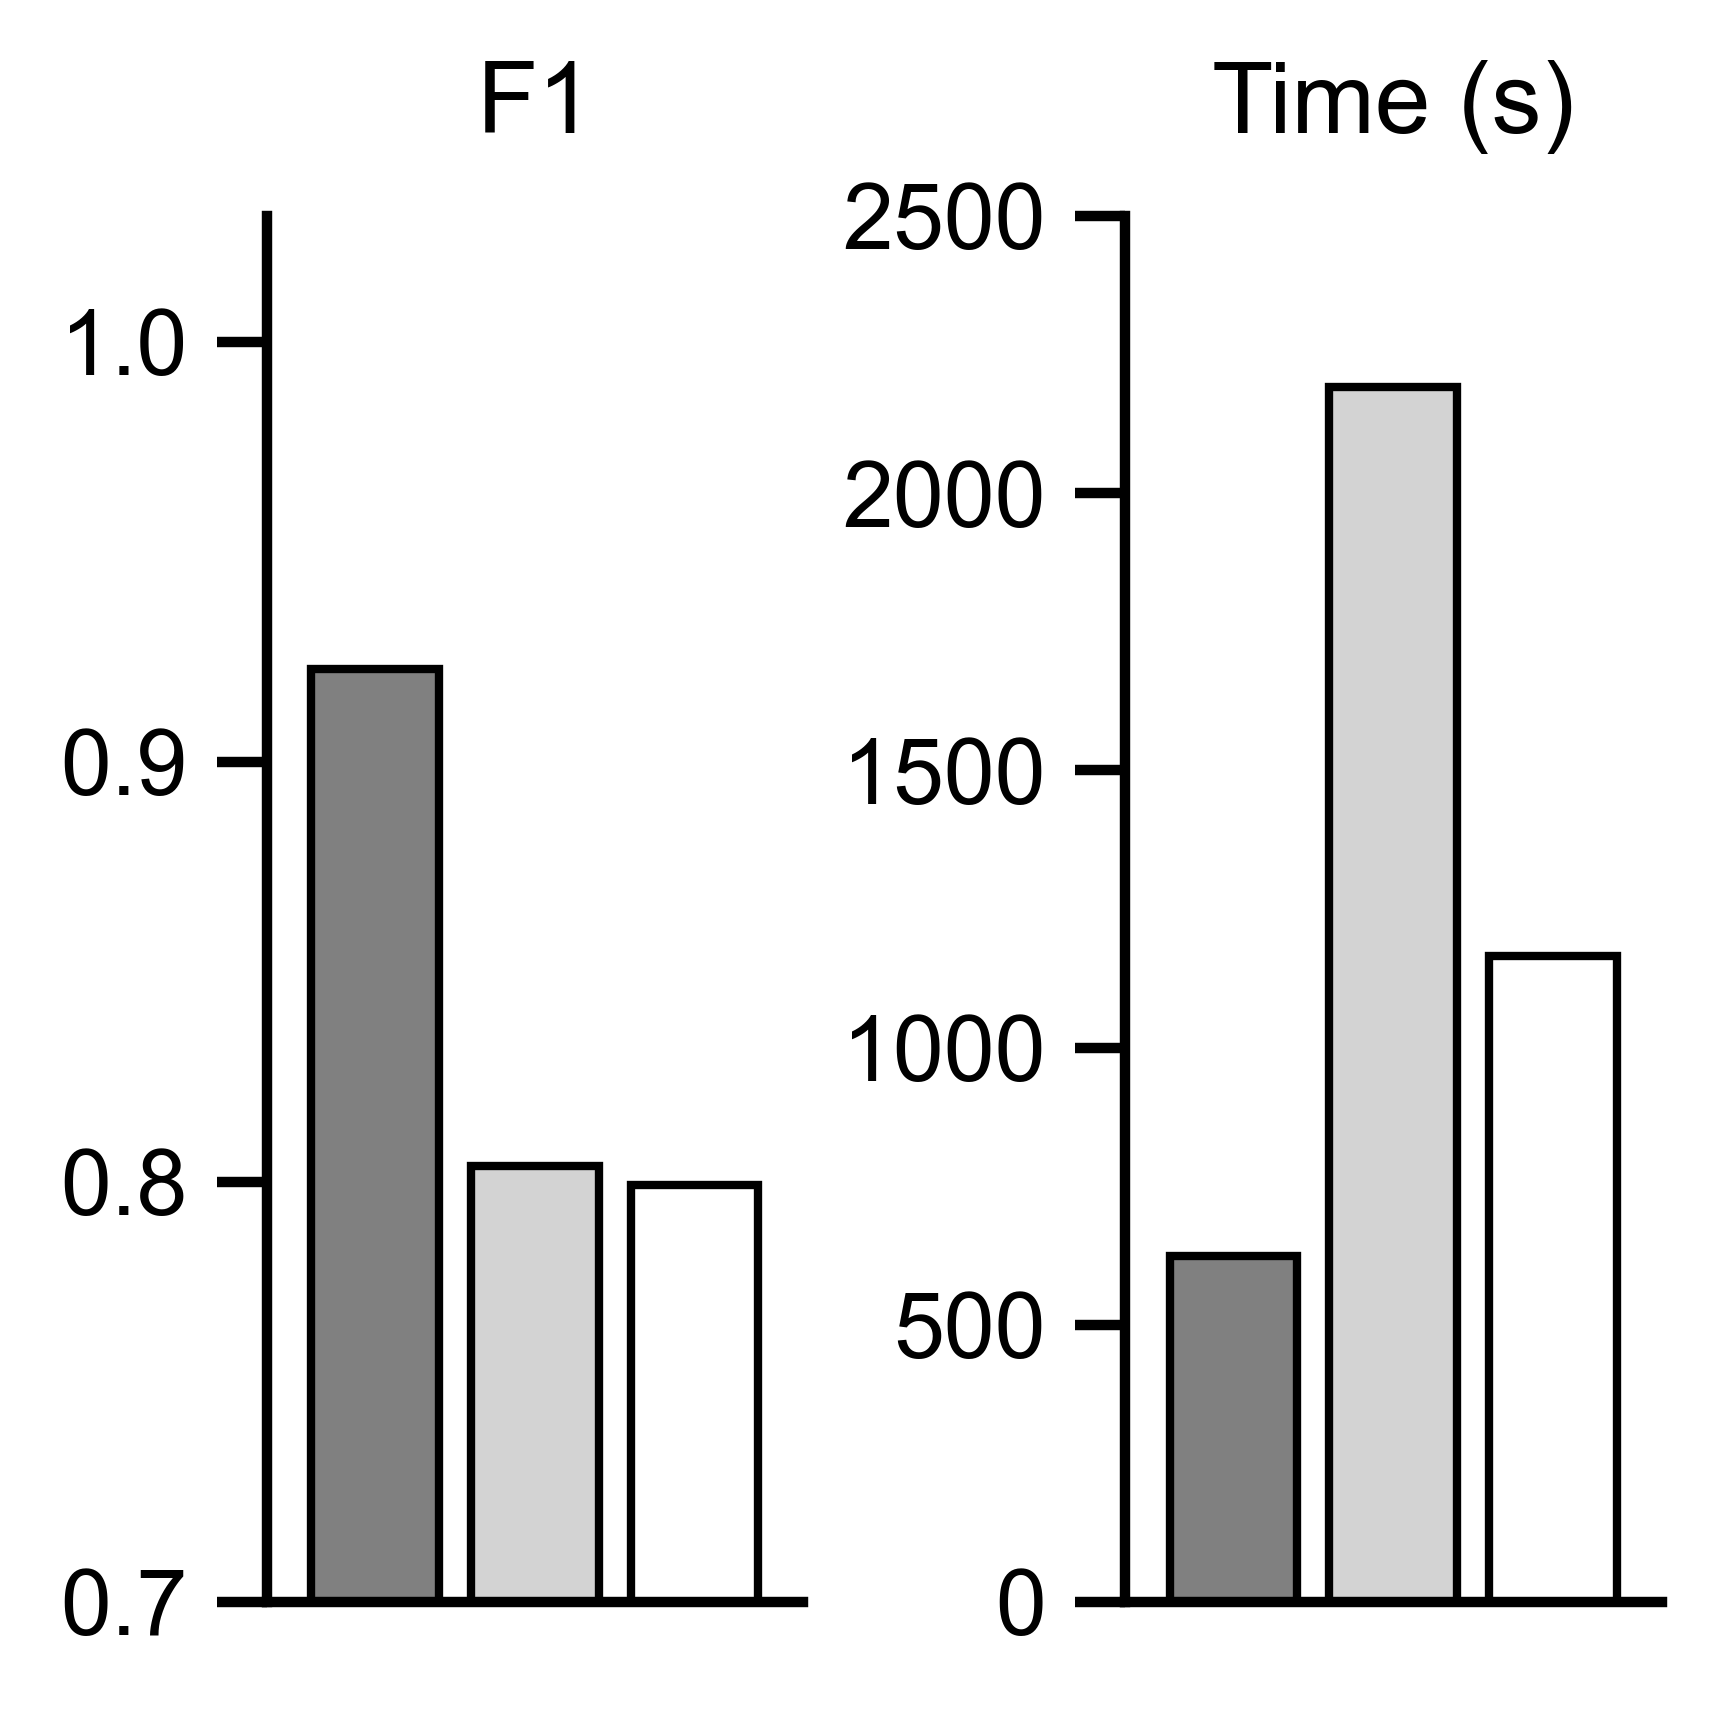

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "zebrafish_results_trained.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4", "u-Segment3D"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4", "stardist": "StarDist", "usegment3d": "u-Segment3D"})
metrics = ["f1", "total_time"]
method_colors = {"NucLogic": "gray", "Cellpose 4": "lightgray", "u-Segment3D": "white"}
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)                    
agg = results.groupby("method")[metrics].agg(["mean", "std"])

x = np.arange(len(methods))          # one group center per method
color =  "black"

fig, axes = plt.subplots(
    figsize=(3, 3),
    dpi=600,
    ncols=2,
    gridspec_kw={"width_ratios": [1,1], "wspace": 0.6},
)


for i, metric in enumerate(metrics):
        means = [agg.loc[m, (metric, "mean")] for m in methods]
        sds   = [agg.loc[m, (metric, "std")]  for m in methods]
        axes[i].bar(x=methods, height=means, capsize=4, linewidth=1,
                label="Time", color=[method_colors[m] for m in methods], edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars

        axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
        axes[i].set_xticklabels("")
        axes[i].spines["top"].set_visible(False)
        axes[i].spines["right"].set_visible(False)

        axes[i].tick_params(left=True, bottom=False) 
        axes[i].tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
        axes[i].margins(x=0.1)
        axes[i].set_ylabel("")

        nuclogic_values = results[results["method"] == "NucLogic"][metric]
        cellpose_values = results[results["method"] == "Cellpose 4"][metric]
        usegment_values = results[results["method"] == "u-Segment3D"][metric]
        star_values = results[results["method"] == "StarDist"][metric]
     
        if i == 0:
                axes[i].set_title("F1", pad=10)
                axes[i].set_ylim(0.7, 1.03)
                axes[i].yaxis.set_major_locator(MaxNLocator(nbins=4))
        else:
                axes[i].set_title("Time (s)", pad=10)
                axes[i].set_ylim(0, 2500)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "zebrafish_results_full.eps"), dpi=600, bbox_inches="tight")
plt.show()

C:\Users\6331823\AppData\Local\Temp\ipykernel_29420\564425438.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")


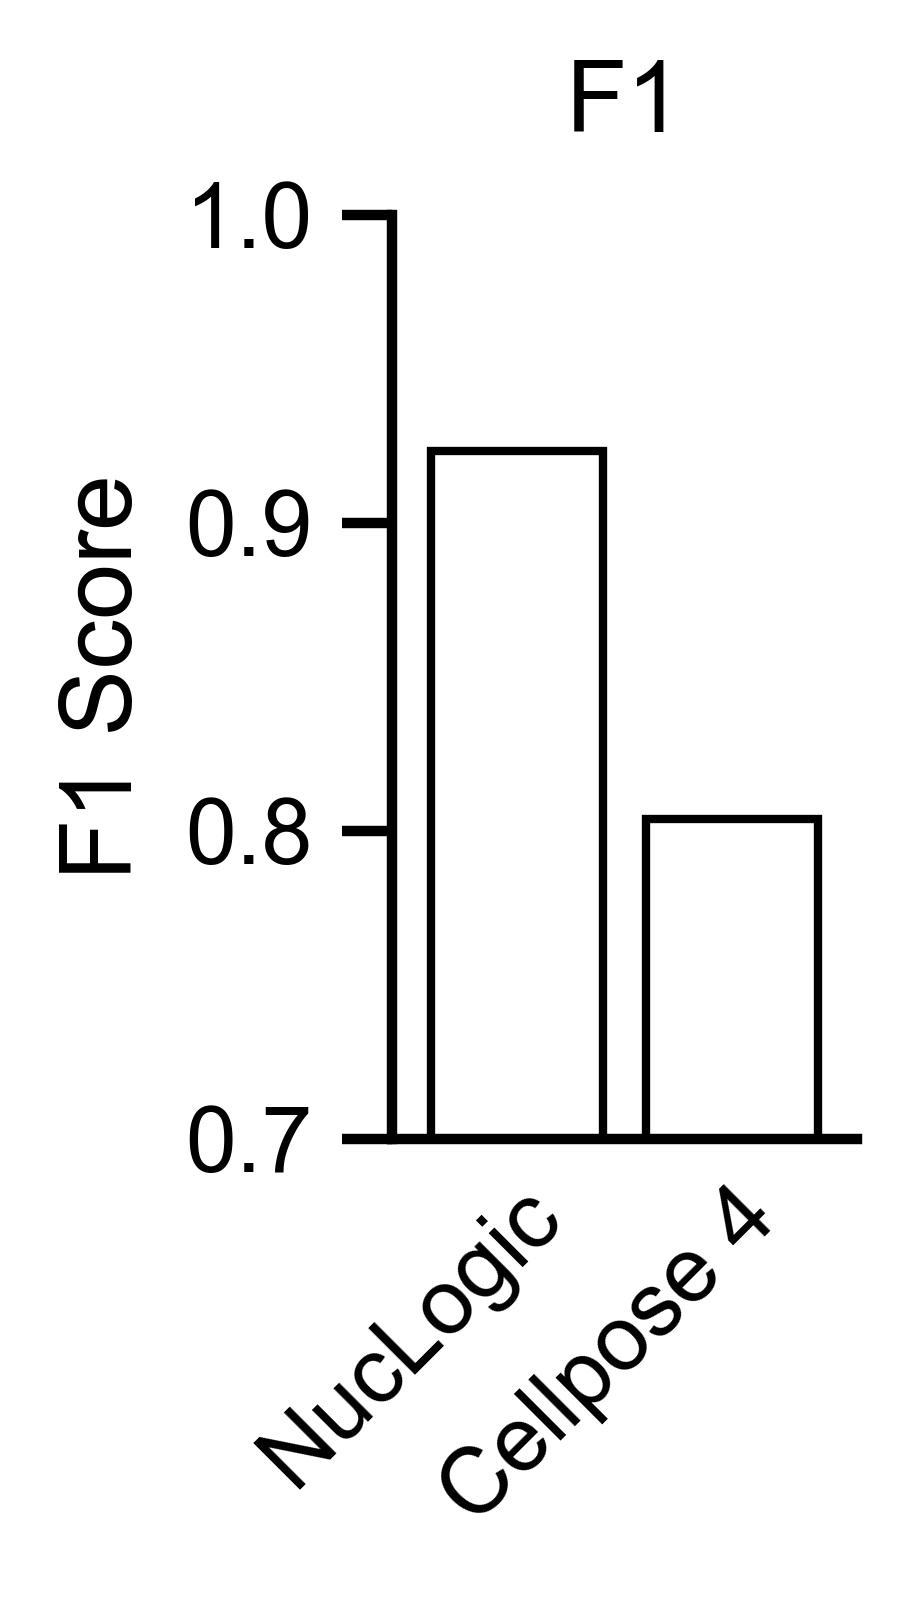

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "zebrafish_results_trained.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4"})
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  

fig, ax = plt.subplots(figsize=(1, 2), dpi=600)

# --- time bar on the RIGHT axis ---
ax.bar(results["method"], results["f1"], capsize=4, linewidth=1,
        label="Time", color="white", edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars
ax.set_ylim(0.7, 1)
ax.set_ylabel("F1 Score")

ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("F1", pad=10)
ax.tick_params(left=True, bottom=False) 
ax.tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
ax.margins(x=0.1)
ax.yaxis.set_ticks([0.7, 0.8, 0.9, 1])

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "zebrafish_results_f1.eps"), dpi=600, bbox_inches="tight")
plt.show()

0     650.135516
1    2190.747435
Name: total_time, dtype: float64


C:\Users\6331823\AppData\Local\Temp\ipykernel_29420\652147048.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")


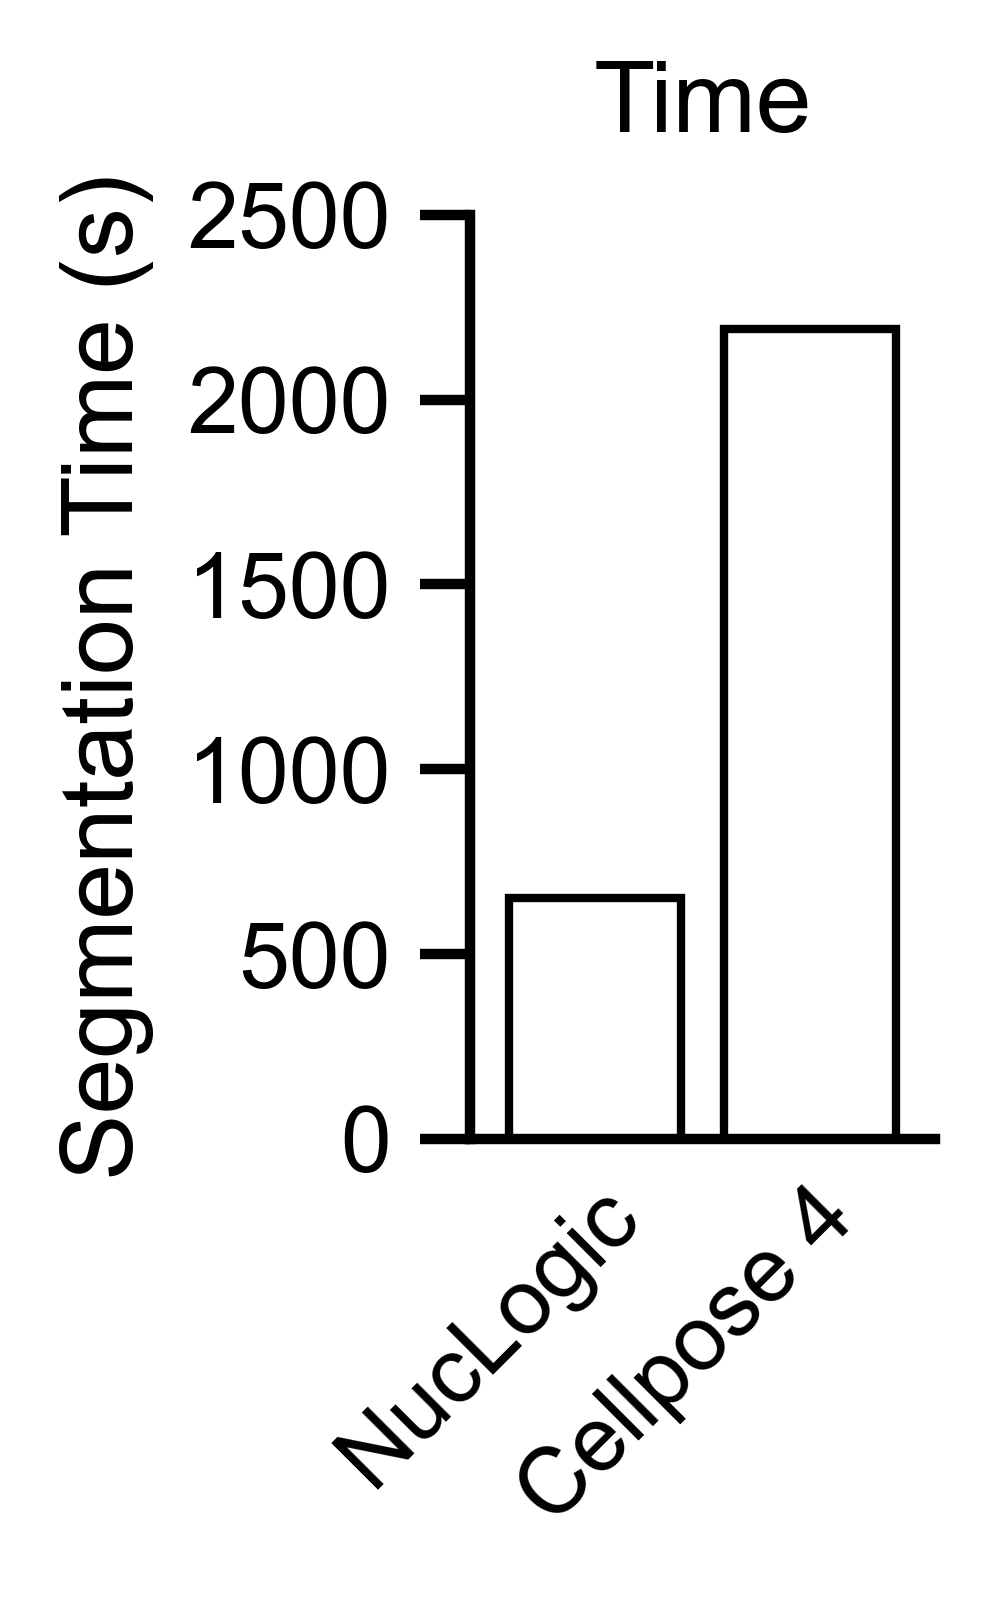

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
import os
import numpy as np
from scipy.stats import ttest_ind

input_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results = pd.read_csv(os.path.join(input_directory, "zebrafish_results_trained.tsv"), sep="\t")
methods = ["NucLogic", "Cellpose 4"]
results["method"] = results["method"].replace({"nuclogic": "NucLogic", "cellpose4": "Cellpose 4"})
sns.set_theme(context="notebook", style="white", rc={
    "text.color":       "black",   # generic text (annotations, legend)
    "axes.labelcolor":  "black",   # x/y axis labels
    "axes.titlecolor":  "black",   # titles
    "xtick.color":      "black",   # x tick MARKS + numbers
    "ytick.color":      "black",   # y tick MARKS + numbers
    "axes.edgecolor":   "black",   # spines (optional, if those look gray too)
})
# mean + sd per method (sd needs >1 sample per method; otherwise NaN -> no error bar)  

fig, ax = plt.subplots(figsize=(1, 2), dpi=600)

# --- time bar on the RIGHT axis ---
print(results["total_time"])
ax.bar(results["method"], results["total_time"], capsize=4, linewidth=1,
        label="Time", color="white", edgecolor=color) # offset a little bit to the right so it doesn't overlap with the score bars
ax.set_ylim(0, 2500)
ax.set_ylabel("Segmentation Time (s)")
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
ax.set_xticklabels(methods, rotation=45, ha="right", rotation_mode="anchor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Time", pad=10)
ax.tick_params(left=True, bottom=False) 
ax.tick_params(axis="x", pad=-2)   # smaller/negative = labels move up
ax.margins(x=0.1)

figure_folder = os.path.join(r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures")
plt.savefig(os.path.join(figure_folder, "zebrafish_results_total_time.eps"), dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
import napari
import os
import tifffile
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)
colormap_seg = {0: '', 1: 'green', 2: 'magenta', 3: 'cyan'}

names = ["Zebrafish_1"]
base_directory = r"C:\Users\6331823\Downloads\NIS3D\NIS3D\NIS3D"
dir = os.path.join(base_directory, names[0])
image = tifffile.imread(os.path.join(dir, "data.tif"))
ground_truth = tifffile.imread(os.path.join(dir, "GroundTruth.tif"))
nuclogic = tifffile.imread(os.path.join(dir, "3d_segmented_nuclogic_trained.tif"))
cp4 = tifffile.imread(os.path.join(dir, "3d_segmented_cp4.tif"))

# def color_mask(mask, gt, tp_list, fp_list, fn_list):
#     # mask-based classes (tp=1, fp=2)
#     lut = np.zeros(int(mask.max()) + 1, dtype=np.uint8)
#     lut[np.asarray(tp_list, dtype=int)] = 1
#     lut[np.asarray(fp_list, dtype=int)] = 2
#     colored = lut[mask]

#     # fn comes from gt, painted on top
#     fn_lut = np.zeros(int(gt.max()) + 1, dtype=np.uint8)
#     fn_lut[np.asarray(fn_list, dtype=int)] = 3
#     colored[fn_lut[gt] == 3] = 3
#     return colored

# nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
# nuclogic_colored = color_mask(nuclogic, ground_truth, nuclogic_results["tp_list"], nuclogic_results["fp_list"], nuclogic_results["fn_list"])
# cp4_results = (centroid_accuracy(ground_truth, cp4))
# cp4_colored = color_mask(cp4, ground_truth, cp4_results["tp_list"], cp4_results["fp_list"], cp4_results["fn_list"])

viewer = napari.Viewer(ndisplay=3)
viewer.grid.enabled = True
scale = (2.5, 0.43, 0.43)

y_half = slice(0, image.shape[1] // 2)
x_half = slice(0, image.shape[2] // 2)

viewer.add_image(image[y_half, x_half], scale=scale)    
viewer.add_labels(ground_truth[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(nuclogic[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)
viewer.add_labels(cp4[y_half, x_half], scale=scale, iso_gradient_mode="smooth", colormap=colormap, opacity=1)

viewer.reset_view()
viewing_angle = (180, 0, 0)
viewer.camera.angles = viewing_angle
# make scale bar visible
viewer.scale_bar.visible = True
viewer.scale_bar.unit = 'µm'
#toggle grid mode on
viewer.grid.enabled = True
# viewer.theme = 'light'


# save screenshot
output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Figures"
napari.run()
# viewer.screenshot(path=os.path.join(output_directory, "zebrafish_data.png"), size=(2160, 3840), canvas_only=True, scale = 1.2)

# # Reset view to the data bounds, then set a side-view camera angle (XZ view)
viewer.camera.center = (24.796264343669097, 237.4340231835281, 402.7615460461847)
viewer.camera.angles = (179.77222044782297, -0.3018545374737001, 1.8301771723984743)
viewer.camera.zoom   = 10.457644595201812
@viewer.bind_key('c')  # press 'c' to capture camera state
def print_camera(viewer):
    print(f"viewer.camera.center = {viewer.camera.center}")
    print(f"viewer.camera.angles = {viewer.camera.angles}")
    print(f"viewer.camera.zoom   = {viewer.camera.zoom}")

viewer.screenshot(path=os.path.join(output_directory, "zebrafish_zoomed.png"), size=(2160, 3840), canvas_only=True, scale = 1.3)

Emmanuel zebrafish

In [ ]:
import napari
import nrrd
import numpy as np


image, header = nrrd.read(r"C:\Users\6331823\Local SSD\EML_zebrafish\MF59_r0c3.nrrd")
image = np.transpose(image, (2, 1, 0))  # transpose to ZYX order
seg, header = nrrd.read(r"C:\Users\6331823\Local SSD\EML_zebrafish\MF59_masks_crop.nrrd")
seg = np.transpose(seg, (2, 1, 0))  # transpose to ZYX order

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image, scale=(0.43, 0.23, 0.23))
viewer.add_labels(seg, scale=(0.43, 0.23, 0.23), iso_gradient_mode="smooth", opacity=1)
# random_indices = np.random.choice(image.shape[0], size=10, replace=False)
# for index in random_indices:
#     slice = image[index, :, :]
#     tifffile.imwrite(os.path.join(r"C:\Users\6331823\Local SSD\EML_zebrafish\model", f"slice_{index}.tif"), slice, compression="zlib", compressionargs={"level": 8})


<Labels layer 'seg' at 0x2410f6e4890>

In [3]:
import nrrd
import numpy as np
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.stitch_3d import stitch_3d
from utils.load_model import load_model
import time
import pandas as pd
import tifffile
from skimage.transform import resize
from scipy import ndimage

input_directory = r"C:\Users\6331823\Local SSD\EML_zebrafish"
names = ["MF59_r0c3.nrrd"]

scale = (0.43, 0.23, 0.23)  # in micrometers



model = load_model(
    os.path.join(input_directory, "model","models", "zebrafish_lightsheet")
)

results = []
for name in names:
    image, header = nrrd.read(os.path.join(input_directory, name))
    image = np.transpose(image, (2, 1, 0))  # transpose to ZYX order
    image = ndimage.zoom(image, 0.25, order=0)

    start_time = time.time()
    mask = segment(image, model)
    tifffile.imwrite(
        os.path.join(input_directory, "2d_segmented_rescaled.tif"),
        mask,
        compression="zlib",
        compressionargs={"level": 8},
    )
    mask = tifffile.imread(os.path.join(input_directory, "2d_segmented_rescaled.tif"))
    segmentation_time = time.time() - start_time


    start_stitch_time = time.time()
    nuclogic = stitch_3d(
        mask,
        image,
        image_type_1="wt",
        breaking_threshold=2,
        scale=scale
    )
    end_time = time.time()
    nuclogic_time = end_time - start_time
    nuclogic_cellpose_time = start_stitch_time - start_time
    nuclogic_stitch_time = end_time - start_stitch_time

    ground_truth, header = nrrd.read(
        os.path.join(input_directory, "MF59_masks_crop.nrrd")
    )
    ground_truth = np.transpose(ground_truth, (2, 1, 0))  # transpose to ZYX order
    nuclogic = resize(nuclogic, ground_truth.shape, order=0)  # rescale back to original size
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_nuclogic_rescaled.tif"),
        nuclogic,
        compression="zlib",
        compressionargs={"level": 8},
    )
    nuclogic = tifffile.imread(os.path.join(input_directory, "3d_segmented_nuclogic_rescaled.tif"))

    nuclogic_results = (centroid_accuracy(ground_truth, nuclogic))
    print(f"centroid accuracy: {nuclogic_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(nuclogic)) - 1}"
    )

    print(f"Segmentation completed in {segmentation_time:.2f} seconds.")
    print(f"Stitching completed in {end_time - start_stitch_time:.2f} seconds.")
    print(f"Total nuclogic time: {end_time - start_time:.2f} seconds.")


    start_cp4 = time.time()
    cp4,_,_ = model.eval(
                    image,
                    diameter=None,
                    normalize=True,
                    flow3D_smooth=0.4,
                    invert=False,
                    resample=True,
                    do_3D=True,
                    z_axis=0,
                    min_size=150,
                    progress=True,
                )
    end_cp4 = time.time()
    cp4_time = end_cp4 - start_cp4

    cp4 = resize(cp4, ground_truth.shape, order=0)  # rescale back to original size
    tifffile.imwrite(
        os.path.join(input_directory, "3d_segmented_cp4_rescaled.tif"),
        cp4,
        compression="zlib",
        compressionargs={"level": 8},
    )

    cp4_results = (centroid_accuracy(ground_truth, cp4))
    print(f"centroid accuracy: {cp4_results}")
    print(
        f"actual amount of cells: {len(np.unique(ground_truth)) - 1}, predicted amount of cells: {len(np.unique(cp4)) - 1}"
    )
    print(f"Cellpose 4 completed in {cp4_time:.2f} seconds with F1 of {cp4_results['f1']:.3f}.")
    print(f"Total nuclogic time: {nuclogic_time:.2f} seconds with F1 of {nuclogic_results['f1']:.3f}.")

    # save results of centroid accuracy and amount of cells to a tsv file

    results_df = pd.DataFrame(
        {
            "method": ["nuclogic", "cellpose4"],
            "f1": [nuclogic_results["f1"], cp4_results["f1"]],
            "precision": [nuclogic_results["precision"], cp4_results["precision"]],
            "recall": [nuclogic_results["recall"], cp4_results["recall"]],
            "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
            "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1],
            "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"]],
            "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"]],
            "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"]],
            "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"]],
            "total_time": [nuclogic_time, cp4_time],
            "nuclogic_2d_time": [nuclogic_cellpose_time, 0],
            "stitching_time": [nuclogic_stitch_time, 0],
        }
    )
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results_df.to_csv(os.path.join(output_directory, "emmanuel_results_rescaled.tsv"), sep="\t", index=False)

Using CUDA for processing.
loaded custom model: zebrafish_lightsheet
Starting 3D stitching process...
Created 58118 unique 2D cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 5141 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 2384 breaks.
    Iteration 2: Made 1853 breaks.
    Iteration 3: Made 1097 breaks.
    Iteration 4: Made 484 breaks.
    Iteration 5: Made 155 breaks.
    Iteration 6: Made 45 breaks.
    Iteration 7: Made 7 breaks.
    Iteration 8: Made 1 breaks.
    Iteration 9: Made 1 breaks.
Finding touching cell pairs...
Found 20059 pairs of touching cells.
Splitted 11147 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 141 small cells, and removed 360 cells without suitable neighbors.
Final stitched mask has 10667 cells.
centroid accuracy: {'true_positives': 9228, 'false_negatives': 1292, 'false_positives': 1439, 'merged_cells': 1010, 'precision': 0.86

In [ ]:
import os
import sys
from pathlib import Path
parent = Path.cwd().parent
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))
from utils.segment import segment
import importlib
import utils.stitch_3d
importlib.reload(sys.modules["utils.stitch_3d"])
from utils.centroid_accuracy import centroid_accuracy
from utils.stitch_3d import stitch_3d
from scipy import ndimage
import nrrd
import numpy as np
from utils.load_model import load_model
from skimage.transform import resize
import tifffile
import time

input_directory = r"C:\Users\6331823\Local SSD\EML_zebrafish"

name = "MF59_r0c3_2"

image_normal, header = nrrd.read(os.path.join(input_directory, f"{name}.nrrd"))
image_normal = np.transpose(image_normal, (2, 1, 0))  # transpose to ZYX order
image_zoomed = ndimage.zoom(image_normal, 0.25, order=0)
images = [image_normal, image_zoomed]
gt , header = nrrd.read(os.path.join(input_directory, "MF59_masks_crop_2.nrrd"))
gt = np.transpose(gt, (2, 1, 0))  # transpose to ZYX order

model = load_model(
    os.path.join(input_directory, "model", "models", "zebrafish_lightsheet")
)

for image in images:
    if image.shape != gt.shape:
        extra_name = "_rescaled"
        sample_name = f"{name}_rescaled"
    else:
        extra_name = ""
        sample_name = name
    # start_nuclogic_cp = time.time()
    # segmented_2d = segment(image, model)
    # end_nuclogic_cp = time.time()
    # nuclogic_cp_time = end_nuclogic_cp - start_nuclogic_cp
    # tifffile.imwrite(
    #     os.path.join(input_directory, f"{name}_2d_segmented{extra_name}.tif"),
    #     segmented_2d,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    segmented_2d = tifffile.imread(os.path.join(input_directory, f"{name}_2d_segmented.tif"))

    # scale = (0.83, 0.46, 0.46)  # in micrometers
    # time0 = time.time()
    # nuclogic_3d = stitch_3d(segmented_2d,   
    #         image,
    #         image_type_1="wt",
    #         breaking_threshold=6,
    #         scale=scale
    #     )
    # end_nuclogic_stitch = time.time()
    # nuclogic_stitch_time = end_nuclogic_stitch - nuclogic_cp_time 
    # nuclogic_time = end_nuclogic_stitch - start_nuclogic_cp

    # if image.shape != gt.shape:
    #     nuclogic_3d = resize(nuclogic_3d, (gt.shape[0], gt.shape[1], gt.shape[2]), order=0)

    # tifffile.imwrite(
    #     os.path.join(input_directory, f"{name}_3d_segmented_nuclogic{extra_name}.tif"),
    #     nuclogic_3d,
    #     compression="zlib",
    #     compressionargs={"level": 8},
    # )
    nuclogic_3d = tifffile.imread(os.path.join(input_directory, f"{name}_3d_segmented_nuclogic.tif"))
    
    nuclogic_accuracy = centroid_accuracy(gt, nuclogic_3d)
    print(f"Nuclogic time: {nuclogic_time:.2f} seconds")
    print(f"Nuclogic time Nuclogic results: {nuclogic_accuracy}")
    #remove nuclogic out of memory
    del nuclogic_3d

    start_usegment = time.time()
    usegment = usegment_stitch(segmented_2d)
    end_usegment = time.time()
    usegment_time = end_usegment - start_usegment
    if image.shape != gt.shape:
        usegment = resize(usegment, (gt.shape[0], gt.shape[1], gt.shape[2]), order=0)

    tifffile.imwrite(
        os.path.join(input_directory, f"{name}_3d_segmented_usegment{extra_name}.tif"),
        usegment,
        compression="zlib",
        compressionargs={"level": 8},
    )
    usegment_accuracy = centroid_accuracy(gt, usegment)
    print(f"u-Segment3D time: {usegment_time:.2f} seconds")
    print(f"u-Segment3D results: {usegment_accuracy}")
    del usegment
    del segmented_2d

    start_cp4 = time.time()
    cp4,_,_ = model.eval(
                    image,
                    diameter=None,
                    normalize=True,
                    flow3D_smooth=0.4,
                    resample=True,
                    do_3D=True,
                    z_axis=0,
                    min_size=150,
                    progress=True,
                )
    end_cp4 = time.time()
    cp4_time = end_cp4 - start_cp4

    if image.shape != gt.shape:
        cp4 = resize(cp4, (gt.shape[0], gt.shape[1], gt.shape[2]), order=0)
    tifffile.imwrite(
        os.path.join(input_directory, f"{name}_3d_segmented_cp4{extra_name}.tif"),
        cp4,
        compression="zlib",
        compressionargs={"level": 8},
    )
    cp4_accuracy = centroid_accuracy(gt, cp4)
    print(f"Cellpose 4 time: {cp4_time:.2f} seconds")
    print(f"Cellpose 4 results: {cp4_accuracy}")

    results_df = pd.DataFrame(
        {
            "method": ["nuclogic", "cellpose4", "usegment3d"],
            "f1": [nuclogic_results["f1"], cp4_results["f1"], usegment_results["f1"]],
            "precision": [nuclogic_results["precision"], cp4_results["precision"], usegment_results["precision"]],
            "recall": [nuclogic_results["recall"], cp4_results["recall"], usegment_results["recall"]],
            "actual_cells": [len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1, len(np.unique(ground_truth)) - 1],
            "predicted_cells": [len(np.unique(nuclogic)) - 1, len(np.unique(cp4)) - 1, len(np.unique(usegment)) - 1],
            "true_positives": [nuclogic_results["true_positives"], cp4_results["true_positives"], usegment_results["true_positives"]],
            "false_positives": [nuclogic_results["false_positives"], cp4_results["false_positives"], usegment_results["false_positives"]],
            "false_negatives": [nuclogic_results["false_negatives"], cp4_results["false_negatives"], usegment_results["false_negatives"]],
            "merged_cells": [nuclogic_results["merged_cells"], cp4_results["merged_cells"], usegment_results["merged_cells"]],
            "total_time": [nuclogic_time, cp4_time, usegment_time],
            "nuclogic_2d_time": [nuclogic_cellpose_time, 0, 0],
            "stitching_time": [nuclogic_stitch_time, 0, 0],
        }
    )
    results_df.insert(0, "sample", name) 
    results.append(results_df)
results_df = pd.concat(results, ignore_index=True)

output_directory = r"C:\Users\6331823\OneDrive - Universiteit Utrecht\PhD\Suijkerbuijk, S.J.E. (Saskia)'s files - Sebastian van Dijk\Manuscript van Dijk NucLogic\Data"
results_df.to_csv(os.path.join(output_directory, "emmanuel_results_full.tsv"), sep="\t", index=False)

In [2]:
import napari
import os
import tifffile
import nrrd
import numpy as np
from napari.utils.colormaps import colormap_utils as cu
colormap = cu.label_colormap(num_colors=1024)

input_directory = r"C:\Users\6331823\Local SSD\EML_zebrafish"
image, header = nrrd.read(os.path.join(input_directory, "MF59_r0c3_2.nrrd"))
gt , header = nrrd.read(os.path.join(input_directory, "MF59_masks_crop_2.nrrd"))
image = np.transpose(image, (2, 1, 0))  # transpose to ZYX order
gt = np.transpose(gt, (2, 1, 0))  # transpose to ZYX order

nuclogic = tifffile.imread(os.path.join(input_directory, "MF59_r0c3_2_3d_segmented_nuclogic.tif"))
# cp4 = tifffile.imread(os.path.join(input_directory, "3d_segmented_cp4.tif"))

scale = (0.43, 0.23, 0.23)  # in micrometers
viewer = napari.Viewer(ndisplay=3)
viewer.add_image(image, scale=scale)
viewer.add_labels(gt, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
viewer.add_labels(nuclogic, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)
# # viewer.add_labels(cp4, scale=scale, iso_gradient_mode="smooth", opacity=1, colormap=colormap)

<Labels layer 'nuclogic' at 0x1d5f11a0c50>

In [9]:
nuclogic_cellpose = stitch_3d(cp4,
        image,
        image_type_1="wt",
        breaking_threshold=6,
        scale=scale
    )

print(f"original cp4 = {centroid_accuracy(gt, cp4)}")
print(f"stitch cp4 = {centroid_accuracy(gt, nuclogic_cellpose)}")

Starting 3D stitching process...
Creating unique mask for properties calculation...
Unique mask created with 348389 unique cells.
Calculated 2D (intensity) properties for all cells
Starting IOU based 3D stitching...
Completed IOU based stitching: 13901 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 463 breaks.
    Iteration 2: Made 16 breaks.
Finding touching cell pairs...
Found 25144 pairs of touching cells.
Splitted 351 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 1549 small cells, and removed 745 cells without suitable neighbors.
Final stitched mask has 12086 cells.
original cp4 = {'true_positives': 9902, 'false_negatives': 618, 'false_positives': 1793, 'merged_cells': 602, 'precision': 0.8466866182129115, 'recall': 0.941254752851711, 'f1': 0.8914697276614899, 'voxel_dice': 0.817455902709105, 'tp_list': [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 

In [35]:
def remove_outside_cells(mask):
    # labels appearing on any of the 6 faces of the volume
    border = np.unique(np.concatenate([
        mask[0].ravel(),  mask[-1].ravel(),      # z faces
        mask[:, 0].ravel(),  mask[:, -1].ravel(),  # y faces
        mask[:, :, 0].ravel(), mask[:, :, -1].ravel(),  # x faces
    ]))
    border = border[border != 0]
    return np.where(np.isin(mask, border), 0, mask)

gt_removed = remove_outside_cells(gt)
nuclogic_removed = remove_outside_cells(nuclogic)
cp4_removed = remove_outside_cells(cp4)

print(f"Nuclogic results after removing outside cells: {centroid_accuracy(gt_removed, nuclogic_removed)}")
print(f"Cellpose 4 results after removing outside cells: {centroid_accuracy(gt_removed, cp4_removed)}")


Nuclogic results after removing outside cells: {'true_positives': 5738, 'false_negatives': 1461, 'false_positives': 749, 'merged_cells': 992, 'precision': 0.8845383073839987, 'recall': 0.7970551465481317, 'f1': 0.8385211164693848, 'voxel_dice': 0.7463302225812244, 'tp_list': [552, 553, 556, 558, 560, 561, 564, 565, 568, 569, 572, 577, 578, 580, 581, 582, 585, 586, 593, 596, 599, 600, 604, 605, 606, 609, 610, 616, 617, 618, 619, 620, 621, 622, 624, 626, 627, 628, 631, 632, 635, 636, 637, 638, 640, 641, 644, 647, 649, 650, 651, 652, 653, 654, 655, 656, 659, 660, 662, 664, 665, 666, 670, 676, 677, 678, 679, 681, 682, 683, 684, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696, 697, 698, 699, 700, 702, 703, 705, 706, 707, 708, 709, 710, 711, 713, 716, 717, 718, 719, 720, 721, 723, 724, 725, 730, 731, 732, 733, 734, 735, 736, 737, 739, 740, 741, 742, 743, 744, 745, 746, 747, 748, 749, 750, 752, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773